# Diabetes Risk Factor Analysis 

**Dataset:** [Diabetes Prediction Dataset - Kaggle](https://www.kaggle.com/code/fareedalianwar/diabetes-prediction/input)  
**Tool:** Python (pandas, plotnine, seaborn, matplotlib)  
**Records:** ~96,000 patients (after deduplication) | **Features:** 8 medical and demographic variables  
**Target:** `diabetes` 
* 0 = Non-Diabetic 
* 1 = Diabetic

---
# SECTION 1: EXPLORATORY DATA ANALYSIS
## Objective

This section explores the dataset visually and statistically to answer a core question:

> **Which patient characteristics are most associated with a diabetes diagnosis and how do they interact?**

Before going into building an ML model that can predict the likelihood of diabetes in patients based on their medical history and demographic details, This EDA phase is designed to surface patterns, test assumptions, and understand the data before any prediction work begins. Each chart is driven by a specific clinical question.

---

## What Was Explored

### 1. Diagnosis Distribution
The dataset is heavily imbalanced, the majority of patients are non-diabetic. This is an important context for the ML section, as class imbalance can bias a model toward always predicting the majority class.

---

### 2. Gender and Diabetes Prevalence
Females have a slightly higher count of diabetic diagnoses than males, but the gap is narrow. 
Gender as a feature in the model shows the odds ratio confirmed it as minimal 
predictive power (0.942), meaning gender alone is not a meaningful driver of diabetes risk 
in this dataset.

---

### 3. Age Group and Diabetes Risk
Diabetes risk rises sharply after 45. Patients aged 50–59 and 60+ account 
for the majority of diabetic cases in this dataset, while patients under 30 show the lowest 
prevalence rates. This confirms age as one of the strongest demographic predictors, every 
decade of age meaningfully increases diabetes risk.

---

### 4. Hypertension and Diabetes
*Hypertensive patients have a markedly higher diabetes rate compared to non-hypertensive patients. This is consistent with clinical literature, where hypertension and Type 2 diabetes frequently co-occur as part of metabolic syndrome.

---

### 5. Heart Disease and Diabetes
Patients with heart disease show a higher diabetes prevalence rate than healthy patients. Like hypertension, this reflects the well-documented overlap between cardiovascular and metabolic conditions.

---

### 6. Smoking History and Diabetes
Former smokers show the highest diabetes rate among all smoking categories. This may reflect survivorship bias (long-term smokers who have since quit are older and sicker on average), or genuine metabolic damage from prior smoking. Current and never-smokers show comparably lower rates.

---

### 7. BMI and Diabetes
Diabetic patients have a noticeably higher average BMI than non-diabetic patients. Elevated BMI is a well-established risk factor for Type 2 diabetes, and this dataset reflects that clearly.

---

### 8. HbA1c Level and Diabetes
Diabetic patients have a substantially higher average HbA1c level. HbA1c (glycated haemoglobin) directly measures average blood sugar over 2–3 months and is one of the primary clinical markers used to diagnose diabetes. This chart confirms it is one of the most discriminating features in the dataset.

---

### 9. Blood Glucose Level and Diabetes
Diabetic patients have significantly higher average blood glucose levels. Along with HbA1c, blood glucose is one of the two strongest numerical predictors of diabetes in this dataset.

---

### 10. Correlation Heatmap
The heatmap reveals that `HbA1c_level` and `blood_glucose_level` have the highest positive correlation with diabetes. `age` and `bmi` show moderate positive correlations. `hypertension` and `heart_disease` show weaker but present correlations. Gender (as encoded) has minimal correlation.

---

### 11. Risk Factor Profiles
Comparing mean values across diabetic vs. non-diabetic groups shows a consistent pattern:

| Feature | Non-Diabetic (avg) | Diabetic (avg) |
|---|---|---|
| Age | Lower | Higher |
| BMI | Lower | Higher |
| HbA1c Level | Lower | Higher |
| Blood Glucose | Lower | Higher |
| Hypertension | Less common | More common |

The diabetic patient profile that emerges: **older age + elevated BMI + high HbA1c + high blood glucose**, often accompanied by hypertension or heart disease. 

---

## Key EDA Takeaways

- **HbA1c and blood glucose are the strongest individual predictors** of diabetes in this dataset, both clinically and statistically.
- **Age is the most important demographic factor.** Risk increases substantially after 45.
- **BMI shows a meaningful but moderate difference** between groups, it's a contributor, not a sole determinant.
- **Binary comorbidities (hypertension, heart disease) amplify risk** rather than cause diabetes directly.
- **Smoking history is nuanced**  the "former smoker" group shows elevated risk, likely confounded by age.
- **The dataset is imbalanced.** This will be addressed in the modelling phase.

---


---
# SECTION 2: Machine Learning - Diabetes Prediction Model

**Models Tested:** Logistic Regression, Random Forest  
**Best Model:** Random Forest (GridSearchCV Tuned)  
**Libraries:** scikit-learn, pandas, numpy, matplotlib

---

## The Problem This Model Solves

In a clinical setting, missing a diabetic patient is far more harmful than a false alarm. A patient incorrectly flagged as diabetic will undergo further testing, an inconvenience. A diabetic patient sent home undiagnosed may face serious, preventable complications.

> **The goal: build a model that predicts diabetes diagnosis and catches as many real diabetic cases as possible.**

This shapes every decision in this section.  
**Recall on the diabetic class is the priority metric**  not overall accuracy.

---

## What Was Built and What It Achieved

Four models were trained and evaluated. Each iteration addressed a specific problem identified in the previous result:

| Model | Recall (Diabetic) | Precision (Diabetic) | Accuracy | ROC-AUC | Problem Identified |
|---|---|---|---|---|---|
| Logistic Regression (default) | 0.63 | 0.86 | 0.96 | 0.96 | Missing 37% of diabetic patients due to class imbalance |
| Logistic Regression (balanced) | 0.88 | 0.42 | 0.88 | 0.96 | Recall improved but precision low - model over-flagging |
| Random Forest (default) | 0.69 | 0.94 | 0.97 | 0.96 | Worse recall than logistic regression - needs tuning |
| **Random Forest (tuned)** ✅ | **0.92** | 0.45 | 0.89 | 0.97 | **Selected - highest recall on validation and test set** |

---

## Conclusion

The tuned Random Forest was selected as the final model. Evaluated on the test set, it identified **1,536 diabetic patients** out of 1,696 missing only **160**. A recall of **0.92** on truly unseen data means the model catches 92 out of every 100 diabetic patients.

The key finding across all four models: **a high accuracy score does not mean a model is clinically useful.** The default logistic regression achieved 96% accuracy while missing 37% of diabetic patients. Recall, not accuracy, is the metric that reflects real-world impact in a medical diagnosis context.

---

## Approach

1. Built a clean modelling ready dataset - dropping visualisation helper columns, encoding categoricals, splitting into train/validation/test (60/20/20)
2. Scaled features using `StandardScaler` fitted on training data only - preventing data leakage
3. Trained **Logistic Regression** as baseline - identified class imbalance, fixed with `class_weight='balanced'`
4. Trained **Random Forest** - tuned with `GridSearchCV` optimising specifically for recall
5. Compared all models on validation set, selected best model - evaluated once on test set


## SECTION 1

#### Imports

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics
from sklearn.metrics import roc_auc_score

import pandas as pd
import numpy as np
import janitor
from plotnine import *
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
diabetes_raw = pd.read_csv('diabetes_prediction_dataset.csv')


#### Data viewing and interrogation

In [3]:
diabetes_raw.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
diabetes_raw.info

<bound method DataFrame.info of        gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              

In [5]:
diabetes_raw.shape

(100000, 9)

In [6]:
diabetes_raw.dtypes

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [7]:
#checking for missing values
diabetes_raw.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
#Checking for duplicates
diabetes_raw.duplicated().sum()

np.int64(3854)

In [9]:
# Viewing the duplicate rows
diabetes_raw[diabetes_raw.duplicated(keep='first')]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
2756,Male,80.0,0,0,No Info,27.32,6.6,159,0
3272,Female,80.0,0,0,No Info,27.32,3.5,80,0
3418,Female,19.0,0,0,No Info,27.32,6.5,100,0
3939,Female,78.0,1,0,former,27.32,3.5,130,0
3960,Male,47.0,0,0,No Info,27.32,6.0,200,0
...,...,...,...,...,...,...,...,...,...
99980,Female,52.0,0,0,never,27.32,6.1,145,0
99985,Male,25.0,0,0,No Info,27.32,5.8,145,0
99989,Female,26.0,0,0,No Info,27.32,5.0,158,0
99990,Male,39.0,0,0,No Info,27.32,6.1,100,0


In [10]:
# Removing duplicates
diabetes = diabetes_raw.drop_duplicates().copy()

In [11]:
diabetes.shape

(96146, 9)

In [12]:
#summary statistics
diabetes.describe().round(2)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.00,96146.00,96146.00,96146.00,96146.00,96146.00,96146.00
mean,41.79,0.08,0.04,27.32,5.53,138.22,0.09
std,22.46,0.27,0.20,6.77,1.07,40.91,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.40,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,59.00,0.00,0.00,29.86,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


In [13]:
#Checking for skewness
# Close to 0 = symmetric. Far from 0 = skewed (tail on one side)
diabetes.skew(numeric_only=True)

age                   -0.062445
hypertension           3.157676
heart_disease          4.642359
bmi                    1.023751
HbA1c_level           -0.054463
blood_glucose_level    0.836489
diabetes               2.903845
dtype: float64

#### Feature Engineering

##### Age classification
| Age group | Label | Clinical Life Stage |
|---|---|---|
| 0 - 12 | Children | Pediatric
| 13 - 18 | Adolescents |
| 19 - 44 | Young Adults |
| 45 - 64 | Middle age |
| 65+ | Older adults | Geriatric

In [14]:
diabetes['age_group'] = pd.cut(diabetes['age'],
                               bins=[0,13,19,45,65,100], right=False,
                               labels=['Children','Adolescents','Young Adults','Middle Age','Older Adults'])

In [15]:
diabetes['age_group'].unique().tolist

<bound method ExtensionArray.tolist of ['Older Adults', 'Middle Age', 'Young Adults', 'Adolescents', 'Children']
Categories (5, object): ['Children' < 'Adolescents' < 'Young Adults' < 'Middle Age' < 'Older Adults']>

In [16]:
diabetes[['age','age_group']].head()

,age,age_group
0,80.0,Older Adults
1,54.0,Middle Age
2,28.0,Young Adults
3,36.0,Young Adults
4,76.0,Older Adults


---
### EDA

EDA QUESTIONS

✅What is the distribution of diabetes diagnosis among patients? (Percentage of diabetic and non-diabetic patients)  
✅What is the gender distribution of patients?  Is diabetes prevalence different between males and females?  
✅Is age correlated with diabetes diagnosis?  
✅Which age group has the most diabetes? (create age group of <30, 30-39, 40-49)  
✅Is hypertension associated with a diabetes diagnosis? Do patients with hypertension have higher diabetes rates?  
✅Is heart disease associated with diabetes diagnosis?   
✅Does smoking status influence diabetes prevalence?   
✅How does BMI differ between diabetic and non-diabetic patients?  
✅How does HbA1c level differ between diabetic and non-diabetic patients?   
✅ Does blood glucose levels differ between diabetic and non diabetic patients?    
✅Which factors show the strongest relationship with diabetes?(Correlation matrix )   
✅What combinations of risk factors characterize diabetic patients? (older + high BMI + high HbA1 = Diabetes)

In [17]:
#Feature relationship visualization
feature_distribution = diabetes[['age', 'bmi','HbA1c_level','blood_glucose_level', 'diabetes']]
feature_distribution

,age,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,25.19,6.6,140,0
1,54.0,27.32,6.6,80,0
2,28.0,27.32,5.7,158,0
3,36.0,23.45,5.0,155,0
4,76.0,20.14,4.8,155,0
...,...,...,...,...,...
99994,36.0,24.60,4.8,145,0
99996,2.0,17.37,6.5,100,0
99997,66.0,27.83,5.7,155,0
99998,24.0,35.42,4.0,100,0


In [18]:
# Reshape data from wide to long format
feature_pivot = feature_distribution.pivot_longer(
    index=['diabetes'],
    column_names=['age', 'bmi','HbA1c_level','blood_glucose_level'],
    names_to='feature',
    values_to='value'
)

# Make diabetes categorical so the plot knows to treat 0 and 1 as groups, not numbers
feature_pivot['diabetes'] = pd.Categorical(feature_pivot['diabetes'], categories=[0, 1])

feature_pivot.head()

,diabetes,feature,value
0,0,age,80.0
1,0,age,54.0
2,0,age,28.0
3,0,age,36.0
4,0,age,76.0


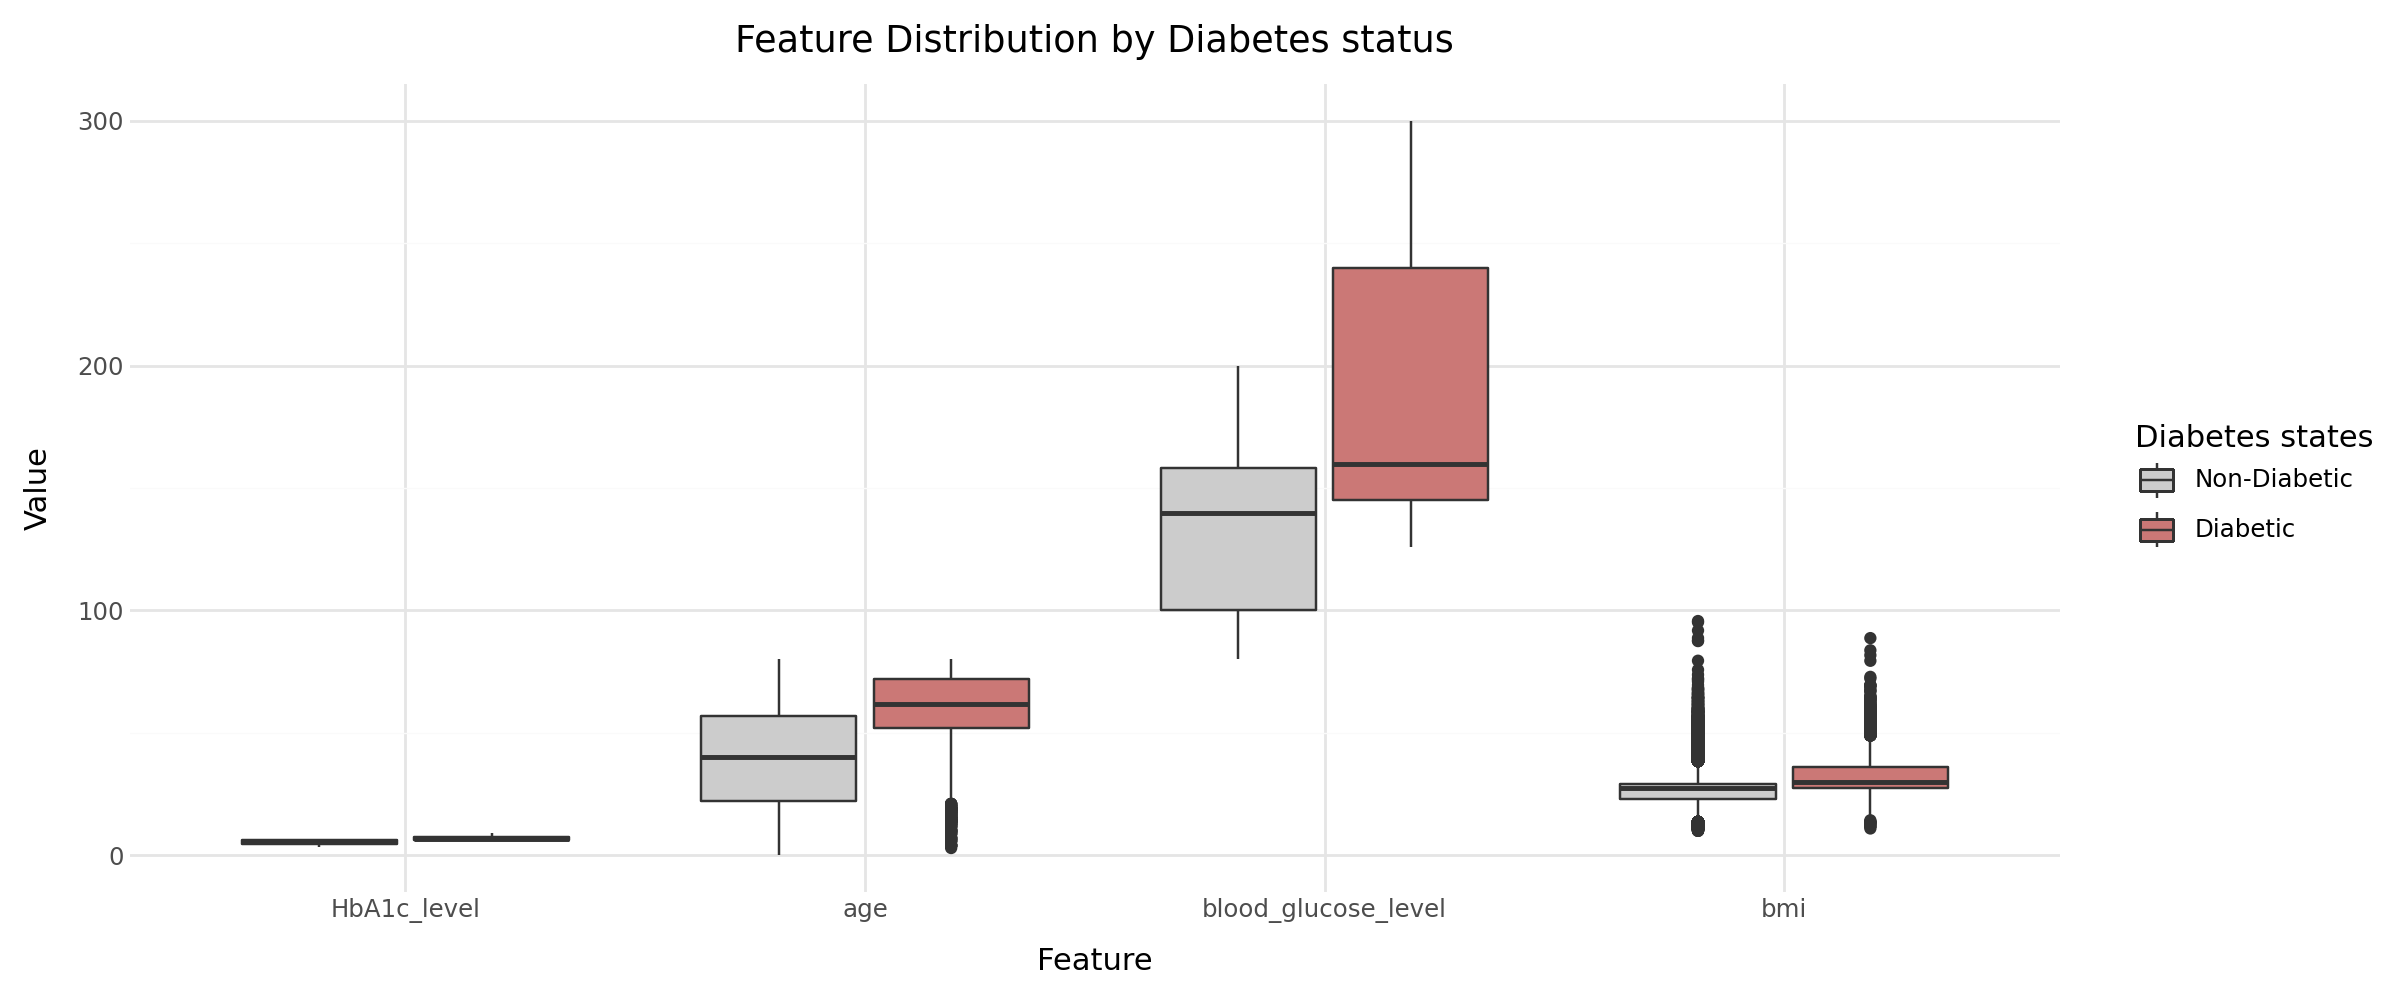

In [19]:
(ggplot(feature_pivot, aes('feature', 'value', fill='diabetes'))
+ geom_boxplot()
+ theme_minimal()
+ theme(figure_size=(12, 5))
+ labs(title='Feature Distribution by Diabetes status',
       x='Feature', y='Value',
     fill='Diabetes states')
+ scale_fill_manual(values={0: '#cccccc', 1: '#cb7876'},
                    labels={0: 'Non-Diabetic', 1: 'Diabetic'}))

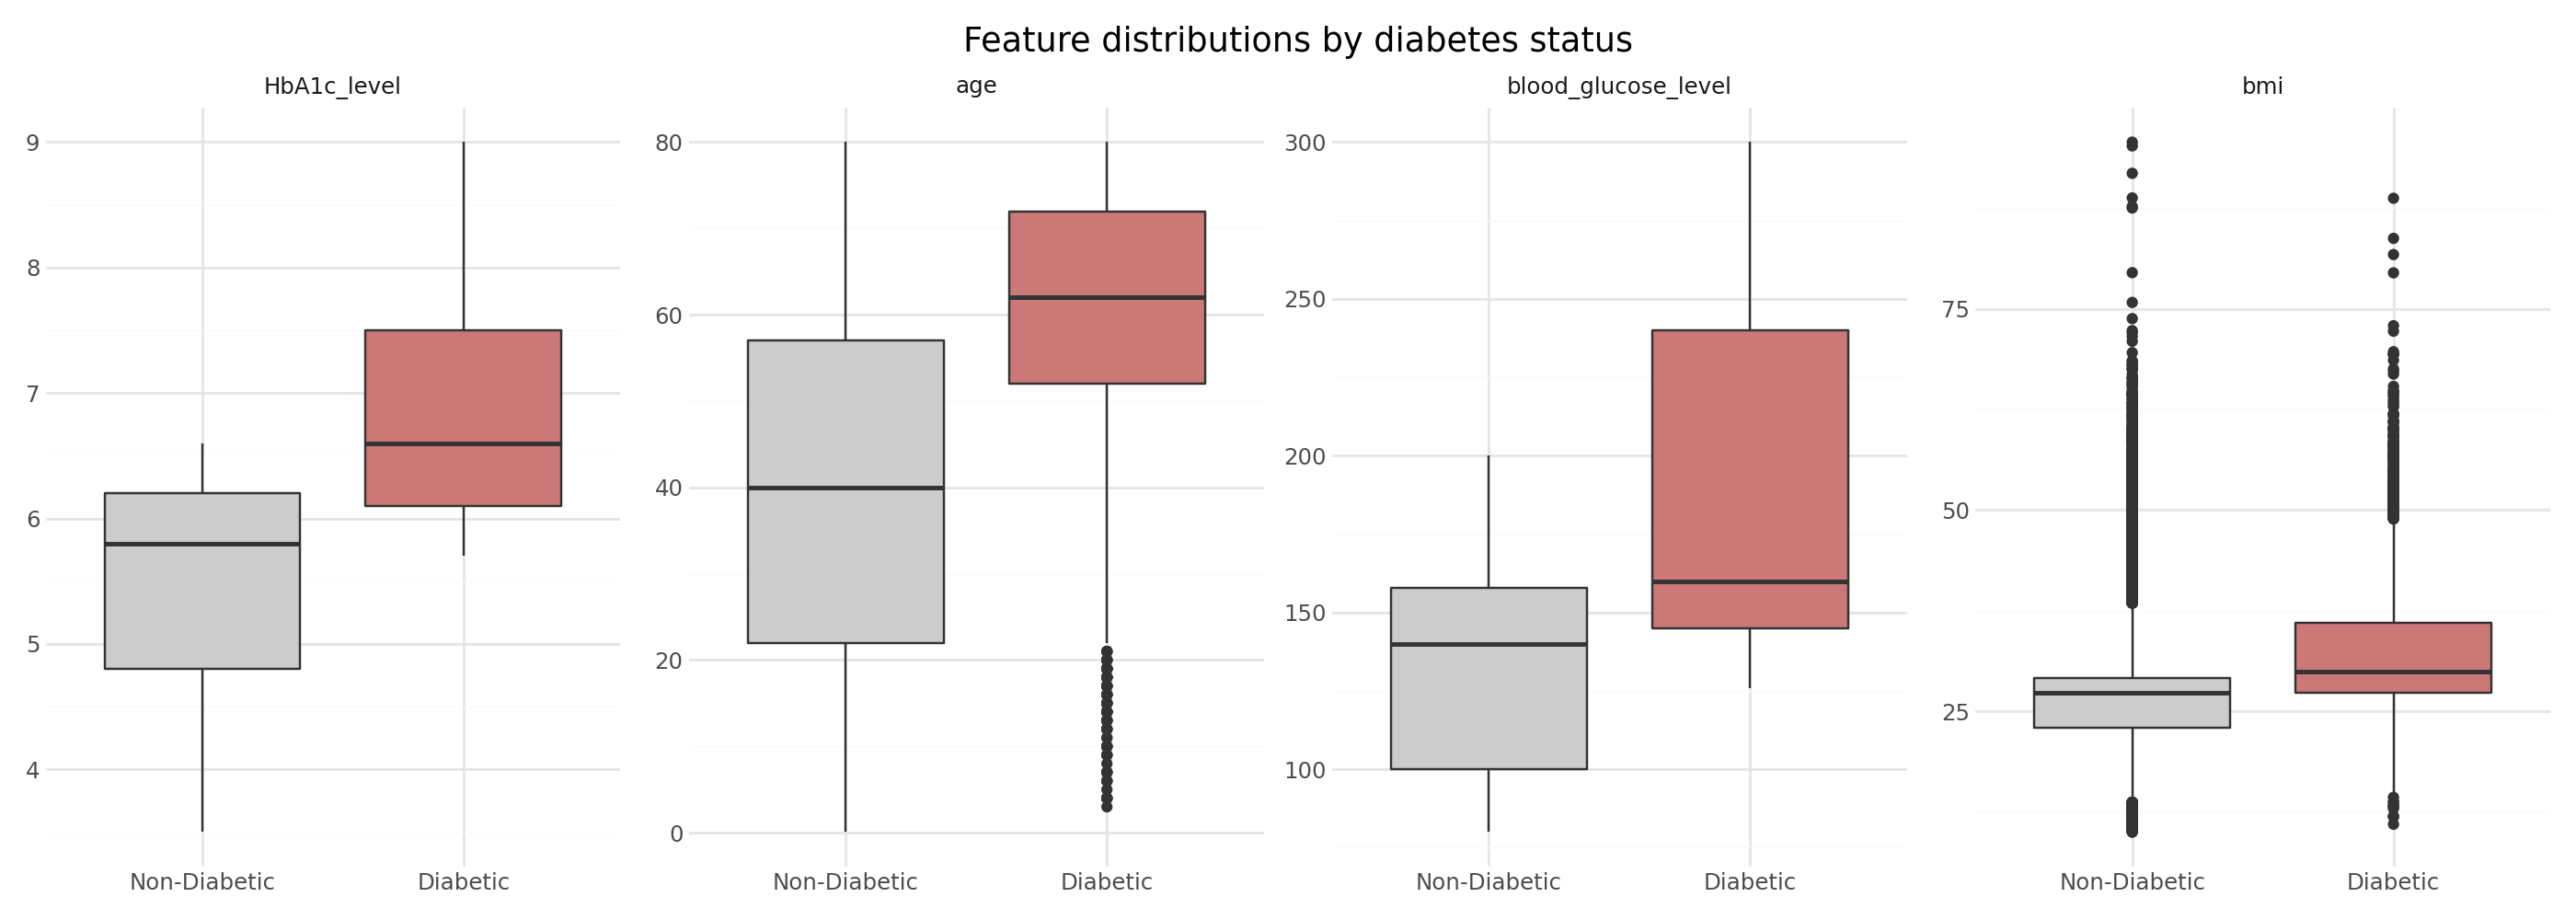

In [20]:
#Each panel in its own axis
chart1 = (ggplot(feature_pivot, aes('diabetes', 'value', fill='diabetes'))
 + geom_boxplot(show_legend=False)
 + facet_wrap('~feature', scales='free_y', ncol=6)
 + theme_minimal()
 + theme(figure_size=(14, 5),
        axis_title_y=element_blank(),
         axis_title_x=element_blank()
        )
 + labs(title='Feature distributions by diabetes status',
        x='Diabetes Status', y='Value',
        fill='Diabetes_status')
 + scale_fill_manual(values={0: '#cccccc', 1: '#cb7876'},
                     labels={0: 'Non-Dietabetic', 1: 'Diabetic'})
 # Add this line to update the x-axis labels:
 + scale_x_discrete(breaks=[0, 1], labels=['Non-Diabetic', 'Diabetic'])
)
chart1

In [21]:
#How many patients are diabetic and non diabetic
# 0 = non-diabetic
# 1=diabetic
diabetes['t_str'] = diabetes['diabetes'].map({0:'Non-Diabetic', 1:'Diabetic'})
data_dis = diabetes['t_str'].value_counts().reset_index(name='patient_count')
data_dis

,t_str,patient_count
0,Non-Diabetic,87664
1,Diabetic,8482


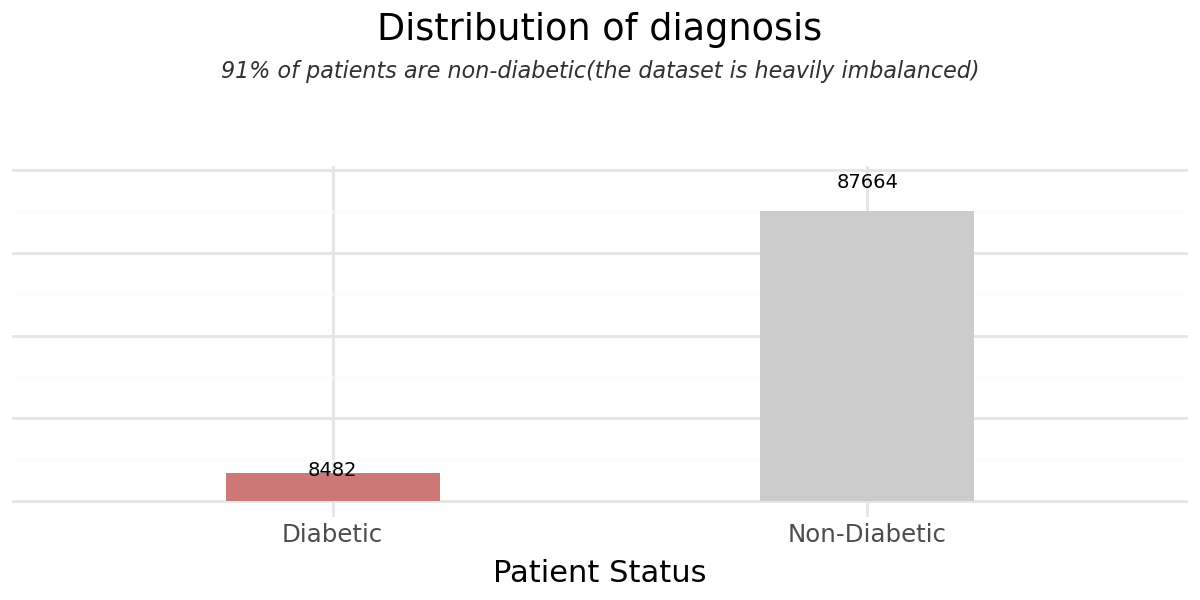

In [22]:
#Diagnosis distribution
(ggplot(data_dis, aes('reorder(t_str,patient_count)', 'patient_count', fill='t_str'))
 + geom_col(show_legend=False, width=0.4)
 +  geom_text(aes(label = 'patient_count'), position = position_stack(vjust = 1.1), size = 7)
 + labs(title='Distribution of diagnosis', subtitle='91% of patients are non-diabetic(the dataset is heavily imbalanced)',
    x='Patient Status',
    y='Patient Count')
 + theme_minimal()
 + theme(plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        axis_line_y = element_blank(),
        axis_text_y = element_blank(),
        axis_ticks_y = element_blank(),
        axis_title_y = element_blank(),
        axis_line_x = element_blank(),
        figure_size=(6,3))
 + scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'}))

---
✅What is the gender distribution of patients? Is diabetes prevalence different between males and females?

In [23]:
gender_dis = diabetes[['t_str','gender']].value_counts().reset_index(name='patient_count')
gender_dis

,t_str,gender,patient_count
0,Non-Diabetic,Female,51714
1,Non-Diabetic,Male,35932
2,Diabetic,Female,4447
3,Diabetic,Male,4035
4,Non-Diabetic,Other,18


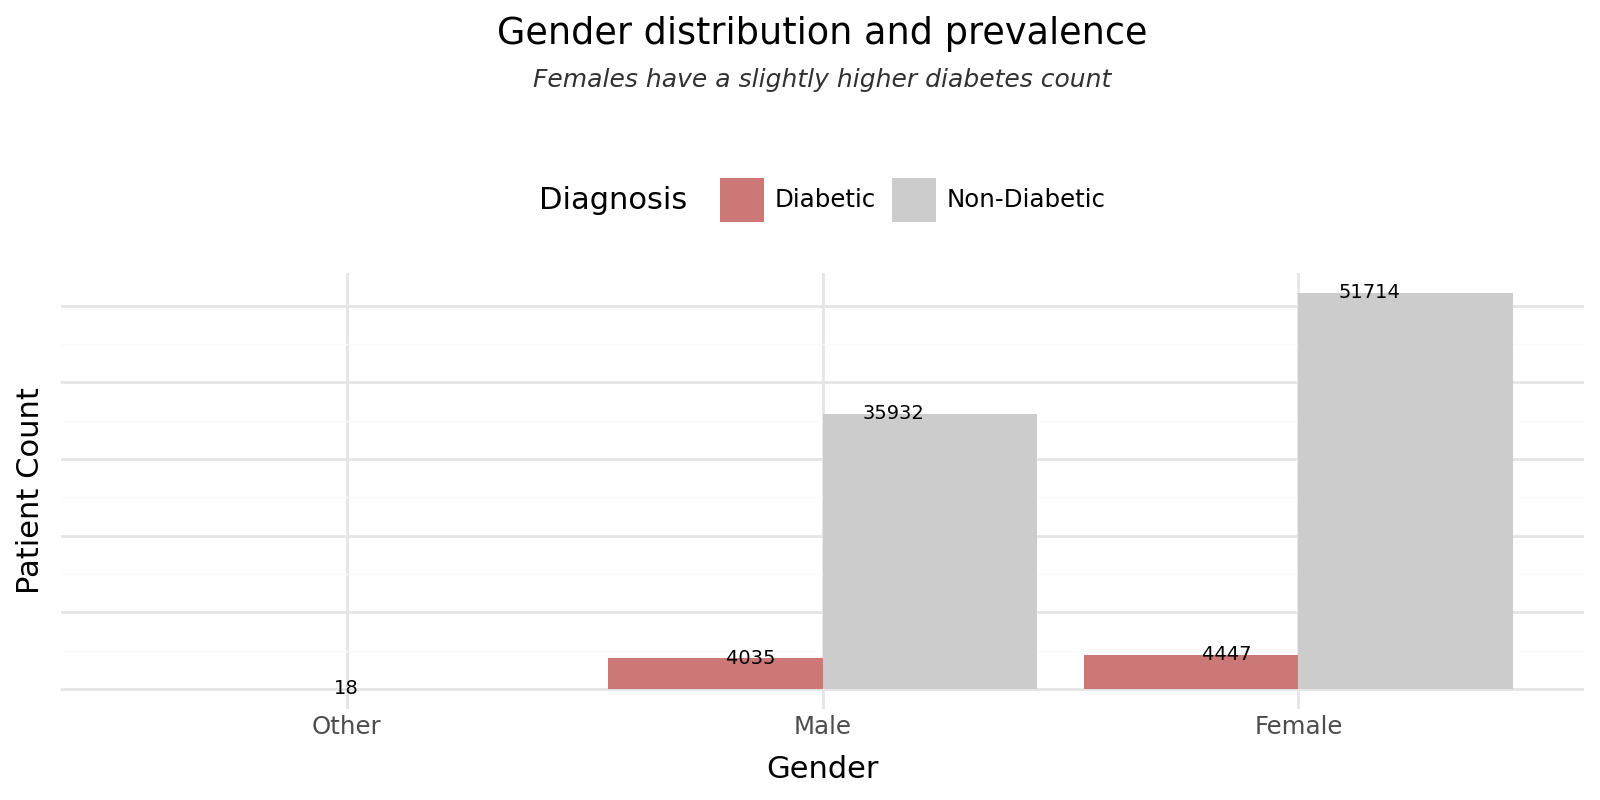

In [24]:
(ggplot(gender_dis, aes(x='reorder(gender, patient_count)', y='patient_count', fill='t_str'))
+ geom_col(position='dodge')
+ geom_text(aes(label = 'patient_count'), 
            position = position_dodge(width = 0.6), size = 7)
+ theme_minimal()
+ labs(title='Gender distribution and prevalence', 
       subtitle='Females have a slightly higher diabetes count',
        x='Gender',
        y='Patient Count',
      fill='Diagnosis')
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
+ theme( plot_subtitle=element_text(size=9,style='italic',color='#313131', ha='center',margin={'b':15}),
    figure_size=(8,4), 
       legend_position='top',
       axis_text_y = element_blank(),
       axis_line_y = element_blank()))

In [25]:
#Isolating only diabetic paients by gender
gender_diabetic_only = gender_dis[gender_dis['t_str']=='Diabetic']
gender_diabetic_only

,t_str,gender,patient_count
2,Diabetic,Female,4447
3,Diabetic,Male,4035


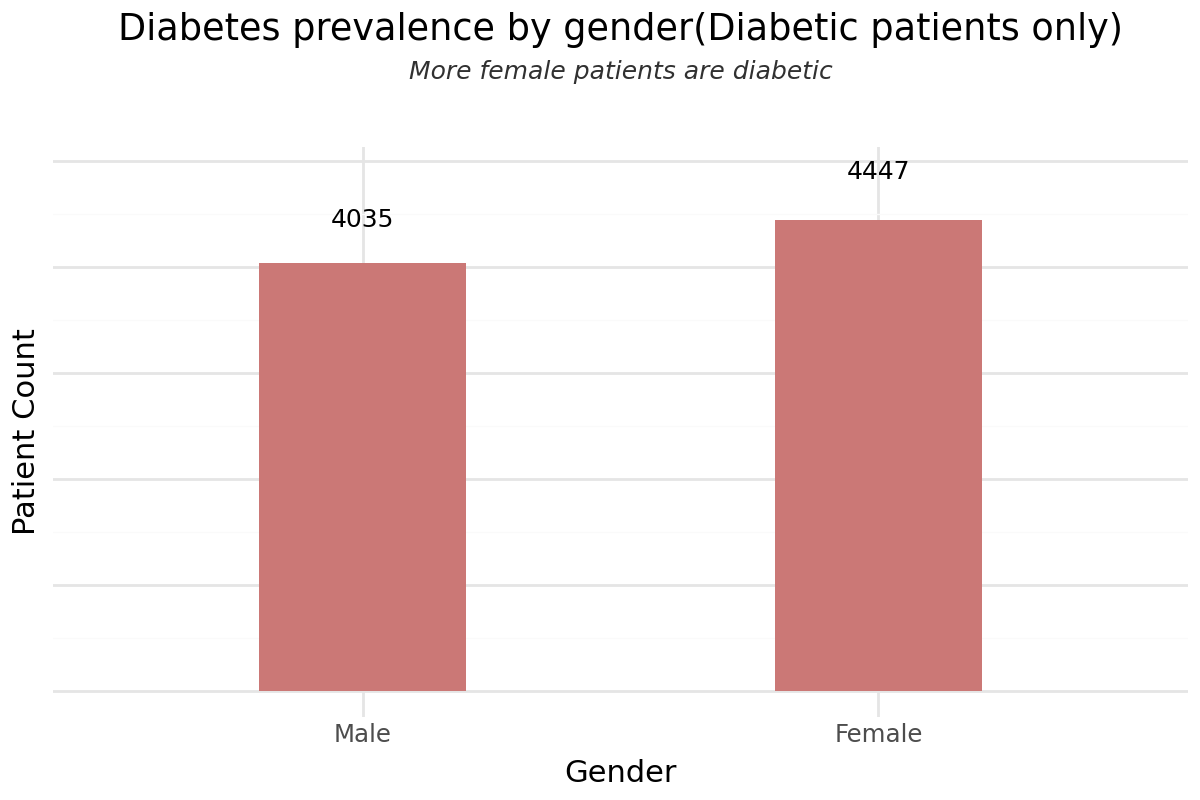

In [26]:
(ggplot(gender_diabetic_only, aes(x='reorder(gender,patient_count)', y='patient_count', fill='gender'))
+ geom_col(width=0.4, show_legend = False)
+ geom_text(aes(label='patient_count'),  
            position = position_stack(vjust = 1.1), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by gender(Diabetic patients only)', 
       subtitle='More female patients are diabetic',
      fill='Status',
     x='Gender', 
      y='Patient Count')
+ scale_fill_manual(values={'Female':'#cb7876', 'Male': '#cb7876', 'Other': '#cb7876'})
+ theme( plot_subtitle=element_text(size=9,style='italic',color='#313131', ha='center',margin={'b':15}),
       figure_size=(6,4), 
       legend_position='top',
       axis_text_y = element_blank(),
       axis_line_y = element_blank()))

---
✅Is age correlated with diabetes diagnosis?

In [27]:
age_dis = diabetes[['t_str','age_group']].value_counts().reset_index(name='patient_count')
age_dis

,t_str,age_group,patient_count
0,Non-Diabetic,Young Adults,31548
1,Non-Diabetic,Middle Age,24517
2,Non-Diabetic,Older Adults,13871
3,Non-Diabetic,Children,11953
4,Non-Diabetic,Adolescents,5775
5,Diabetic,Older Adults,3785
6,Diabetic,Middle Age,3591
7,Diabetic,Young Adults,1014
8,Diabetic,Adolescents,56
9,Diabetic,Children,36


In [28]:
#isolating only diabetic patients?
positive_count = diabetes[diabetes['diabetes']==True].groupby('age_group', observed=True).size().reset_index(name='positive_patient_count')
positive_count

,age_group,positive_patient_count
0,Children,36
1,Adolescents,56
2,Young Adults,1014
3,Middle Age,3591
4,Older Adults,3785


In [29]:
age_dis['total_cat'] = age_dis.groupby('age_group', observed=True)['patient_count'].transform('sum')
age_dis

,t_str,age_group,patient_count,total_cat
0,Non-Diabetic,Young Adults,31548,32562
1,Non-Diabetic,Middle Age,24517,28108
2,Non-Diabetic,Older Adults,13871,17656
3,Non-Diabetic,Children,11953,11989
4,Non-Diabetic,Adolescents,5775,5831
5,Diabetic,Older Adults,3785,17656
6,Diabetic,Middle Age,3591,28108
7,Diabetic,Young Adults,1014,32562
8,Diabetic,Adolescents,56,5831
9,Diabetic,Children,36,11989


In [30]:
age_dis['pct'] = (age_dis['patient_count']/age_dis['total_cat']*100).round(1)
age_dis

,t_str,age_group,patient_count,total_cat,pct
0,Non-Diabetic,Young Adults,31548,32562,96.9
1,Non-Diabetic,Middle Age,24517,28108,87.2
2,Non-Diabetic,Older Adults,13871,17656,78.6
3,Non-Diabetic,Children,11953,11989,99.7
4,Non-Diabetic,Adolescents,5775,5831,99.0
5,Diabetic,Older Adults,3785,17656,21.4
6,Diabetic,Middle Age,3591,28108,12.8
7,Diabetic,Young Adults,1014,32562,3.1
8,Diabetic,Adolescents,56,5831,1.0
9,Diabetic,Children,36,11989,0.3


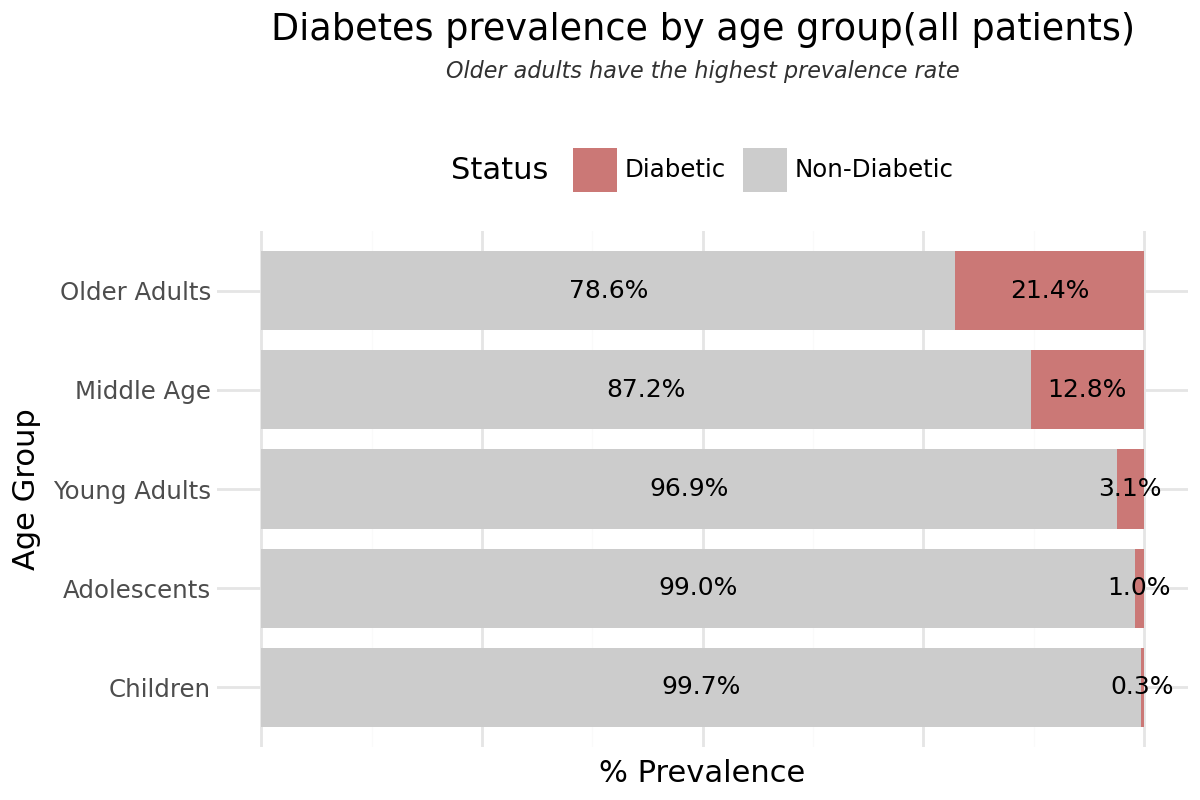

In [31]:
(ggplot(age_dis, aes(x='reorder(age_group,pct)', y='pct', fill='t_str'))
+ geom_col(position='stack',width=0.8)
+ coord_flip()
+ geom_text(aes(label=age_dis['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 0.5), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by age group(all patients)', 
       subtitle='Older adults have the highest prevalence rate',
      fill='Status',
     x='Age Group', 
      y='% Prevalence')
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_x = element_blank(),
       axis_line_x = element_blank(),
       axis_line_y=element_blank()))

In [32]:
diabetic_only = age_dis[age_dis['t_str']=='Diabetic']
diabetic_only

,t_str,age_group,patient_count,total_cat,pct
5,Diabetic,Older Adults,3785,17656,21.4
6,Diabetic,Middle Age,3591,28108,12.8
7,Diabetic,Young Adults,1014,32562,3.1
8,Diabetic,Adolescents,56,5831,1.0
9,Diabetic,Children,36,11989,0.3


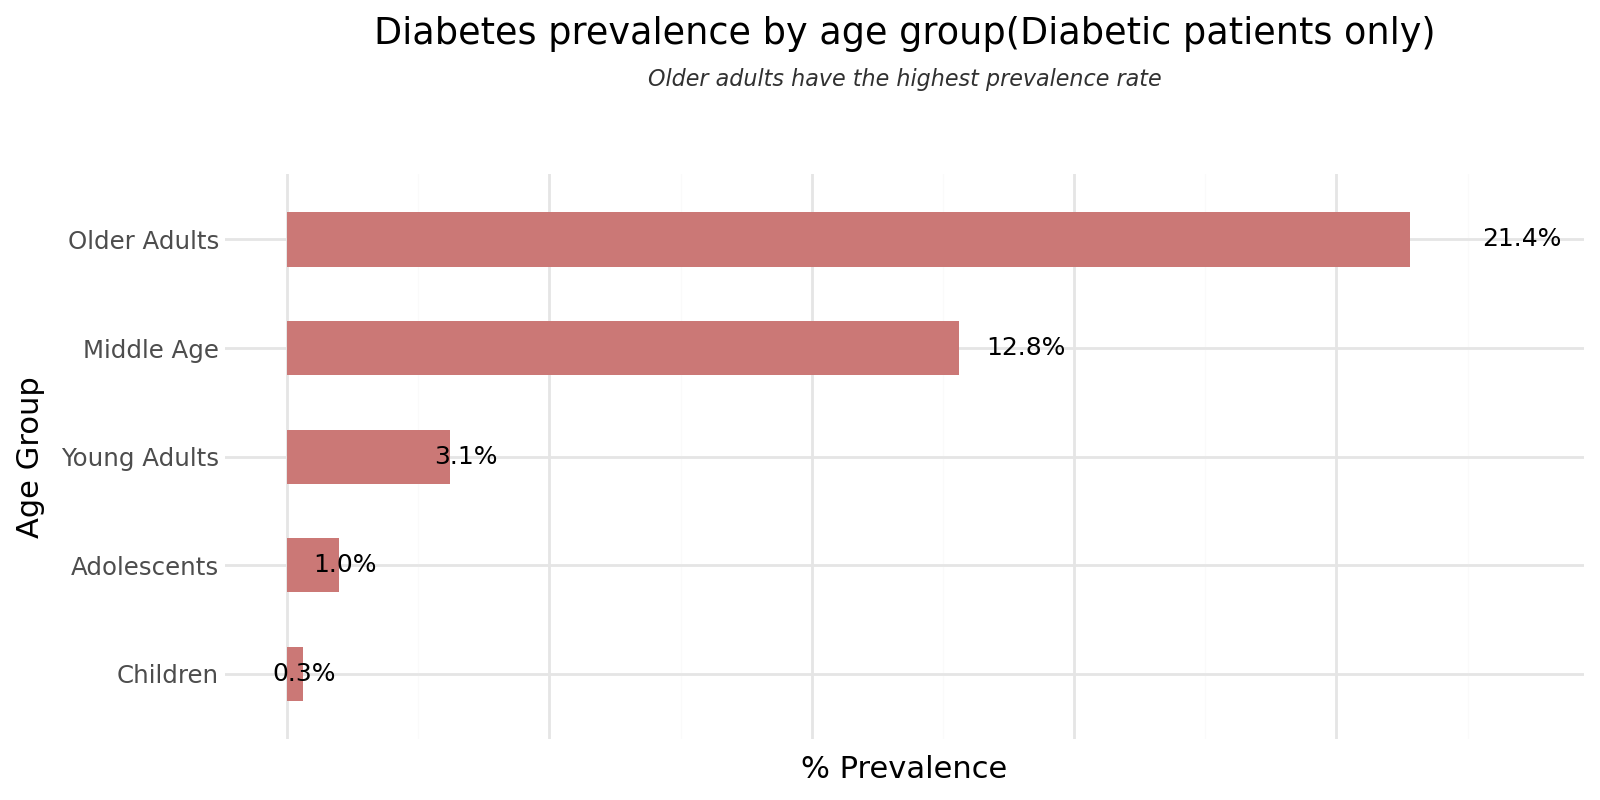

In [33]:
(ggplot(diabetic_only, aes(x='reorder(age_group,pct)', y='pct', fill='age_group'))
+ geom_col(width=0.5, show_legend = False)
+ coord_flip()
+ geom_text(aes(label=diabetic_only['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 1.1), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by age group(Diabetic patients only)',
       subtitle='Older adults have the highest prevalence rate',
       fill='Status',
       x='Age Group', 
       y='% Prevalence')
+ scale_fill_manual(values={'Older Adults':'#cb7876', 'Middle Age': '#cb7876', 'Young Adults': '#CB7876','Adolescents': '#cb7876', 
                            'Children': '#cb7876'})
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(8,4), 
       legend_position='top',
       axis_text_x = element_blank(),
       axis_line_y = element_blank()))

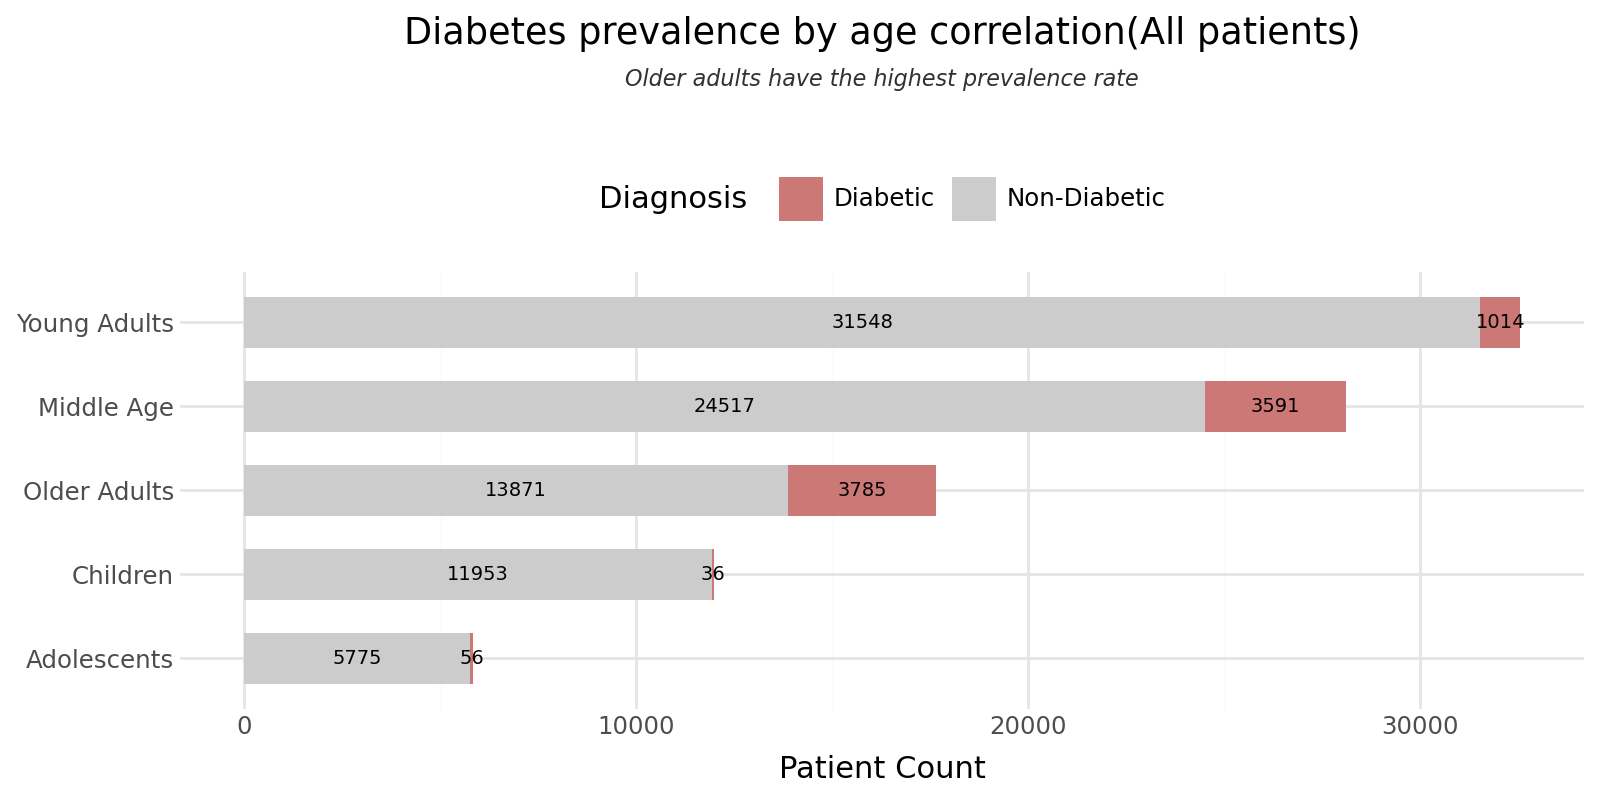

In [34]:
(ggplot(age_dis, aes(x='reorder(age_group, patient_count)', y='patient_count', fill='t_str'))
+ geom_col(width=0.6)
+ coord_flip()
+ geom_text(aes(label = 'patient_count'), 
            position = position_stack(vjust = 0.5), size = 7)
+ theme_minimal()
+ labs(title='Diabetes prevalence by age correlation(All patients)', 
      subtitle='Older adults have the highest prevalence rate',
        x='Group',
        y='Patient Count',
      fill='Diagnosis')
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        axis_title_y=element_blank(),
        figure_size=(8,4), 
       legend_position='top'))

---
✅Which age group has the most diabetes? (create age group of <30, 30-39, 40-49)

In [35]:
diabetes['age_band'] = pd.cut(diabetes['age'],
                             bins=[0,30,40,50,60,100], right=False,
                             labels=['<30', '30-39','40-49', '50-59', '60+'])

In [36]:
age_band_dis = diabetes[['t_str','age_band']].value_counts().reset_index(name='patient_count')
age_band_dis

,t_str,age_band,patient_count
0,Non-Diabetic,<30,30900
1,Non-Diabetic,60+,19057
2,Non-Diabetic,40-49,13063
3,Non-Diabetic,50-59,12558
4,Non-Diabetic,30-39,12086
5,Diabetic,60+,4918
6,Diabetic,50-59,1857
7,Diabetic,40-49,998
8,Diabetic,30-39,435
9,Diabetic,<30,274


In [37]:
#isolating only diabetic patients
positive_count = diabetes[diabetes['diabetes']==True].groupby('age_band', observed=True).size().reset_index(name='positive_patient_count')
positive_count

,age_band,positive_patient_count
0,<30,274
1,30-39,435
2,40-49,998
3,50-59,1857
4,60+,4918


In [38]:
age_band_dis['total_cat'] = age_band_dis.groupby('age_band', observed=True)['patient_count'].transform('sum')
age_band_dis

,t_str,age_band,patient_count,total_cat
0,Non-Diabetic,<30,30900,31174
1,Non-Diabetic,60+,19057,23975
2,Non-Diabetic,40-49,13063,14061
3,Non-Diabetic,50-59,12558,14415
4,Non-Diabetic,30-39,12086,12521
5,Diabetic,60+,4918,23975
6,Diabetic,50-59,1857,14415
7,Diabetic,40-49,998,14061
8,Diabetic,30-39,435,12521
9,Diabetic,<30,274,31174


In [39]:
age_band_dis['pct'] = (age_band_dis['patient_count']/age_band_dis['total_cat']*100).round(1)
age_band_dis

,t_str,age_band,patient_count,total_cat,pct
0,Non-Diabetic,<30,30900,31174,99.1
1,Non-Diabetic,60+,19057,23975,79.5
2,Non-Diabetic,40-49,13063,14061,92.9
3,Non-Diabetic,50-59,12558,14415,87.1
4,Non-Diabetic,30-39,12086,12521,96.5
5,Diabetic,60+,4918,23975,20.5
6,Diabetic,50-59,1857,14415,12.9
7,Diabetic,40-49,998,14061,7.1
8,Diabetic,30-39,435,12521,3.5
9,Diabetic,<30,274,31174,0.9


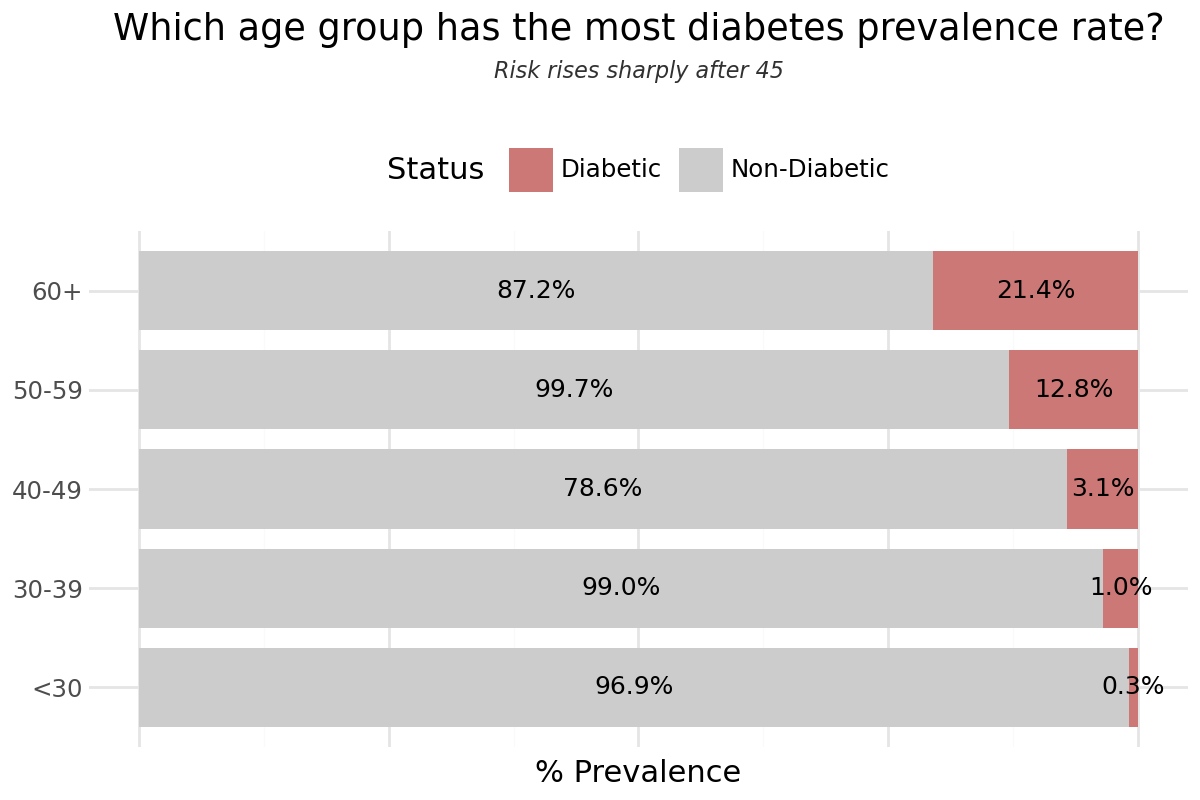

In [40]:
(ggplot(age_band_dis, aes(x='reorder(age_band,pct)', y='pct', fill='t_str'))
+ geom_col(position='stack',width=0.8)
+ coord_flip()
+ geom_text(aes(label=age_dis['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 0.5), size = 9)
+ theme_minimal()
+ labs(title='Which age group has the most diabetes prevalence rate?', 
       subtitle='Risk rises sharply after 45',
      fill='Status',
     x='Age Band', 
      y='% Prevalence')
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_x = element_blank(),
       axis_line_x = element_blank(),
       axis_title_y=element_blank()))

In [41]:
diabetic_band_only = age_band_dis[age_band_dis['t_str']=='Diabetic']

diabetic_band_only

,t_str,age_band,patient_count,total_cat,pct
5,Diabetic,60+,4918,23975,20.5
6,Diabetic,50-59,1857,14415,12.9
7,Diabetic,40-49,998,14061,7.1
8,Diabetic,30-39,435,12521,3.5
9,Diabetic,<30,274,31174,0.9


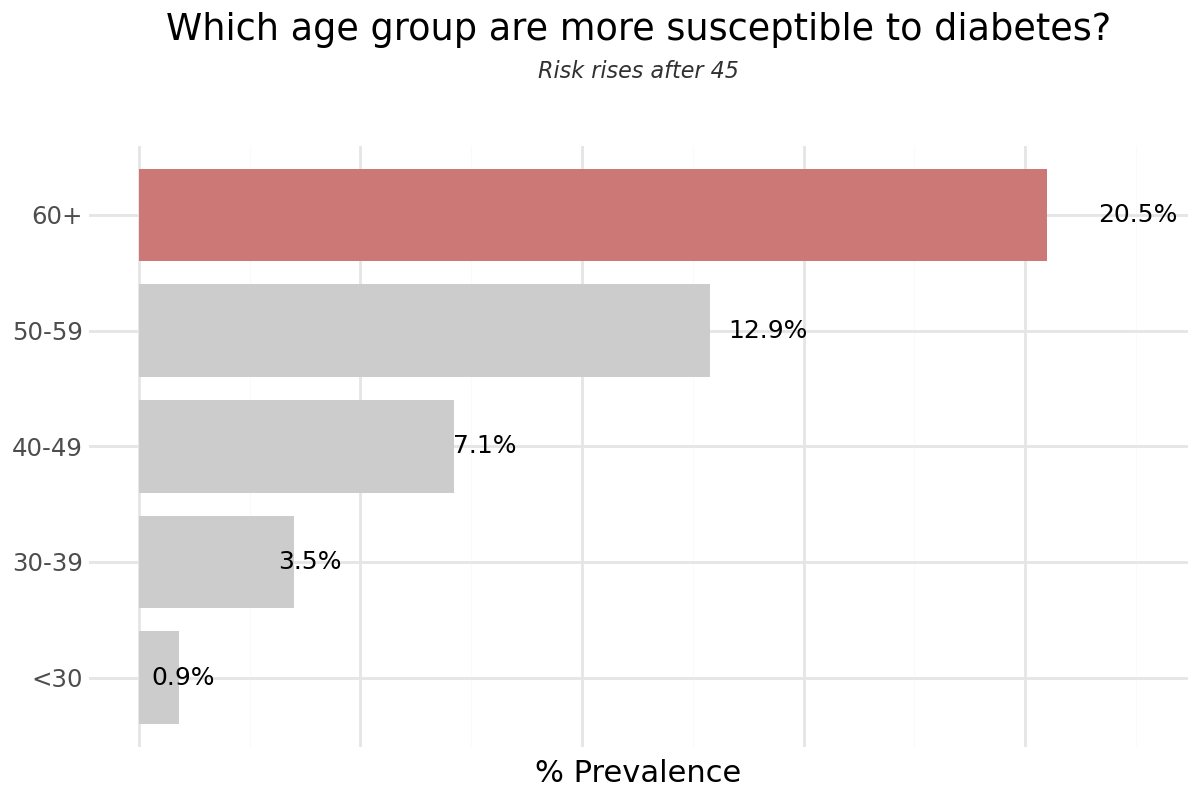

In [42]:
(ggplot(diabetic_band_only, aes(x='reorder(age_band,pct)', y='pct', fill='age_band'))
+ geom_col(position='stack',width=0.8, show_legend=False)
+ coord_flip()
+ geom_text(aes(label=diabetic_band_only['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 1.1), size = 9)
+ theme_minimal()
+ labs(title='Which age group are more susceptible to diabetes?',
       subtitle='Risk rises after 45',
      fill='Status',
     x='Age Band', 
      y='% Prevalence')
+ scale_fill_manual(values={'<30':'#cccccc', '30-39': '#cccccc', '40-49': '#cccccc','50-59': '#cccccc', 
                            '60+': '#cb7876'})
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_x = element_blank(),
       axis_line_x = element_blank(),
       axis_title_y=element_blank()))

---
✅Is hypertension associated with a diabetes diagnosis? (Do patients with hypertension have higher diabetes rates)

In [43]:
diabetes['hypertension'].value_counts()

hypertension
0    88685
1     7461
Name: count, dtype: int64

In [44]:
diabetes['hyp_str'] = diabetes['hypertension'].map({0:'Non-hypertensive', 1:'Hypertensive'})

In [45]:
hyp_dis = diabetes[['t_str','hyp_str']].value_counts().reset_index(name='patient_count')
hyp_dis

,t_str,hyp_str,patient_count
0,Non-Diabetic,Non-hypertensive,82289
1,Diabetic,Non-hypertensive,6396
2,Non-Diabetic,Hypertensive,5375
3,Diabetic,Hypertensive,2086


In [46]:
hyp_dis['total_cat'] = hyp_dis.groupby('hyp_str')['patient_count'].transform('sum')
hyp_dis

,t_str,hyp_str,patient_count,total_cat
0,Non-Diabetic,Non-hypertensive,82289,88685
1,Diabetic,Non-hypertensive,6396,88685
2,Non-Diabetic,Hypertensive,5375,7461
3,Diabetic,Hypertensive,2086,7461


In [47]:
hyp_dis['pct'] = (hyp_dis['patient_count']/hyp_dis['total_cat']*100).round(1)
hyp_dis

,t_str,hyp_str,patient_count,total_cat,pct
0,Non-Diabetic,Non-hypertensive,82289,88685,92.8
1,Diabetic,Non-hypertensive,6396,88685,7.2
2,Non-Diabetic,Hypertensive,5375,7461,72.0
3,Diabetic,Hypertensive,2086,7461,28.0


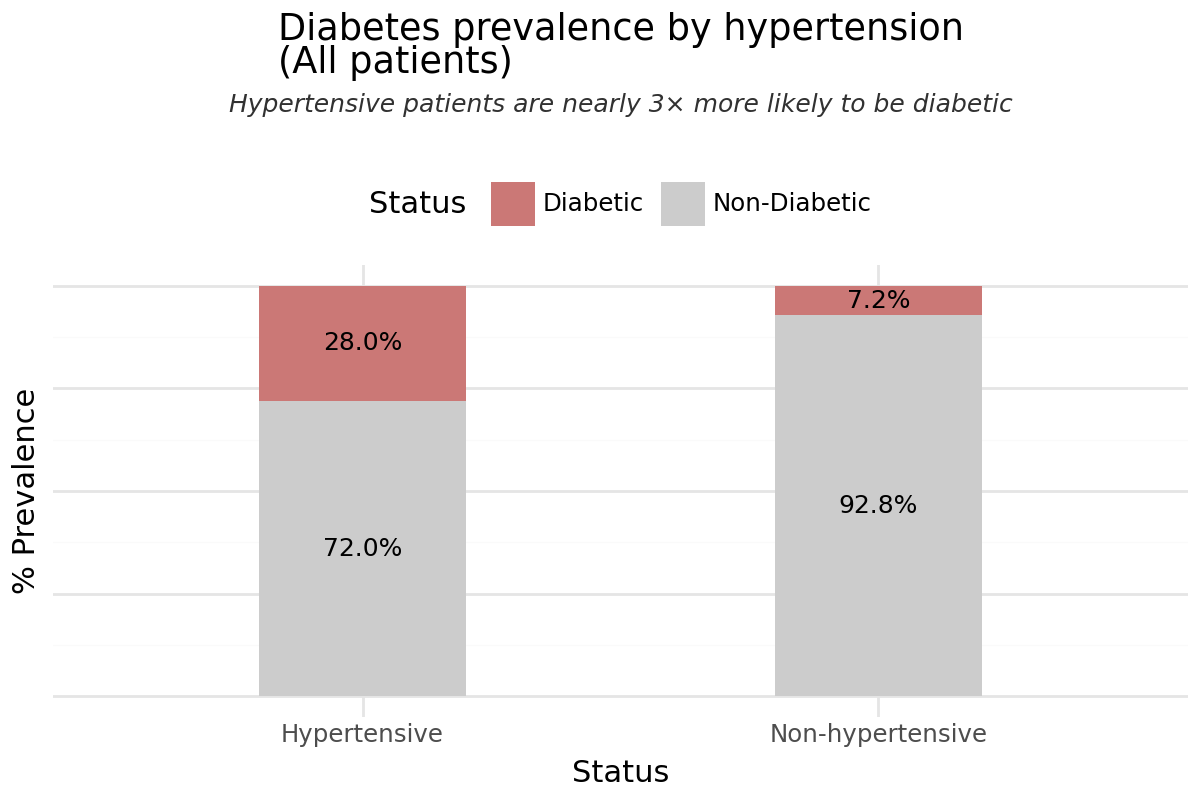

In [48]:
(ggplot(hyp_dis, aes(x='reorder(hyp_str,pct)', y='pct', fill='t_str'))
+ geom_col(position='stack',width=0.4)
+ geom_text(aes(label=hyp_dis['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 0.5), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by hypertension\n(All patients)', 
       subtitle='Hypertensive patients are nearly 3× more likely to be diabetic',
      fill='Status',
     x='Status', 
      y='% Prevalence')
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
+ theme(plot_subtitle=element_text(size=9,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_y = element_blank(),
       axis_line_y = element_blank()))

In [49]:
# Isolating only diabetic patients

hyp_diabetic = hyp_dis[hyp_dis['t_str']=='Diabetic']
hyp_diabetic

,t_str,hyp_str,patient_count,total_cat,pct
1,Diabetic,Non-hypertensive,6396,88685,7.2
3,Diabetic,Hypertensive,2086,7461,28.0


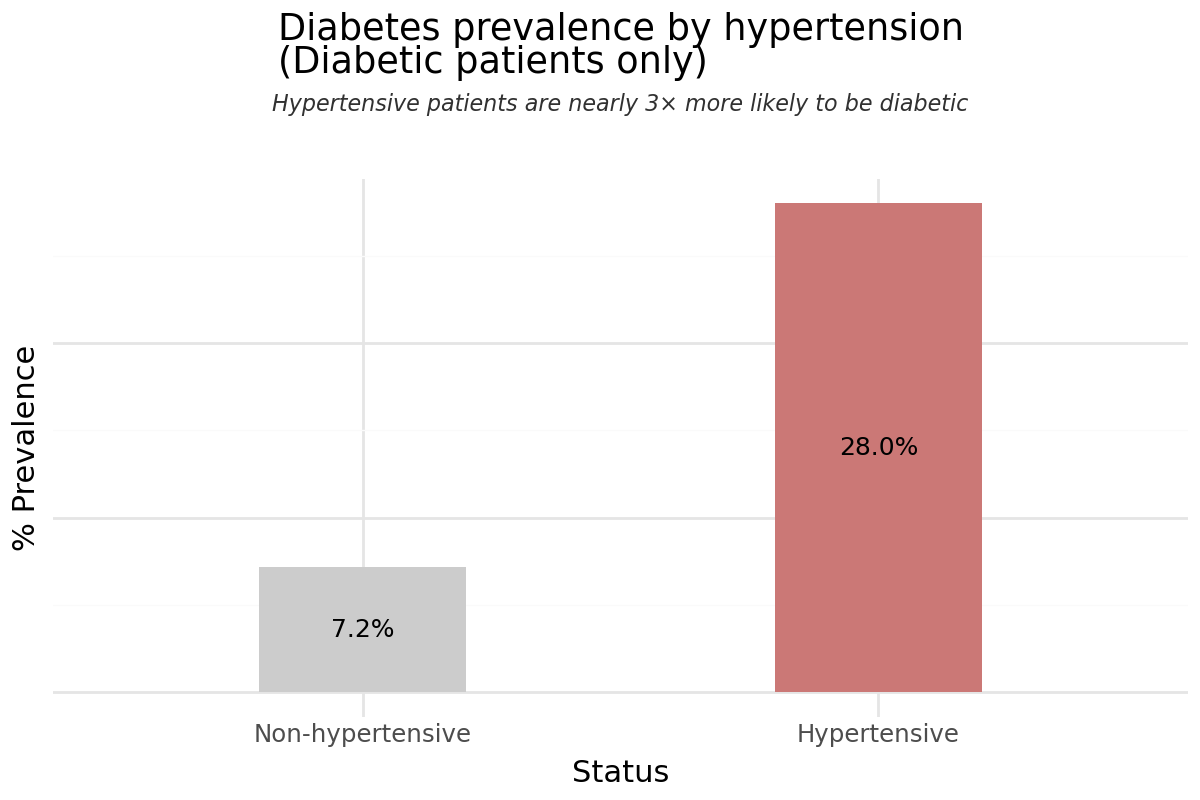

In [50]:
(ggplot(hyp_diabetic, aes(x='reorder(hyp_str,pct)', y='pct', fill='hyp_str'))
+ geom_col(width=0.4, show_legend = False)
+ geom_text(aes(label=hyp_diabetic['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 0.5), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by hypertension\n(Diabetic patients only)', 
       subtitle='Hypertensive patients are nearly 3× more likely to be diabetic',
      fill='Status',
     x='Status', 
      y='% Prevalence')
+ scale_fill_manual(values={'Hypertensive':'#cb7876', 'Non-hypertensive': '#cccccc'})
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_y = element_blank(),
       axis_line_y = element_blank()))

---
✅Is heart disease associated with diabetes diagnosis?

In [51]:
diabetes['heart_str'] = diabetes['heart_disease'].map({0:'Healthy', 1:'Heart Disease'})

In [52]:
diabetes['heart_str'].value_counts()

heart_str
Healthy          92223
Heart Disease     3923
Name: count, dtype: int64

In [53]:
heart_dis = (diabetes.groupby(['heart_str', 't_str']).size().reset_index(name='patient_count'))
heart_dis

,heart_str,t_str,patient_count
0,Healthy,Diabetic,7215
1,Healthy,Non-Diabetic,85008
2,Heart Disease,Diabetic,1267
3,Heart Disease,Non-Diabetic,2656


In [54]:
heart_dis['total_cat'] = heart_dis.groupby('heart_str')['patient_count'].transform('sum')
heart_dis

,heart_str,t_str,patient_count,total_cat
0,Healthy,Diabetic,7215,92223
1,Healthy,Non-Diabetic,85008,92223
2,Heart Disease,Diabetic,1267,3923
3,Heart Disease,Non-Diabetic,2656,3923


In [55]:
heart_dis['pct'] = (heart_dis['patient_count']/heart_dis['total_cat']*100).round(1)
heart_dis

,heart_str,t_str,patient_count,total_cat,pct
0,Healthy,Diabetic,7215,92223,7.8
1,Healthy,Non-Diabetic,85008,92223,92.2
2,Heart Disease,Diabetic,1267,3923,32.3
3,Heart Disease,Non-Diabetic,2656,3923,67.7


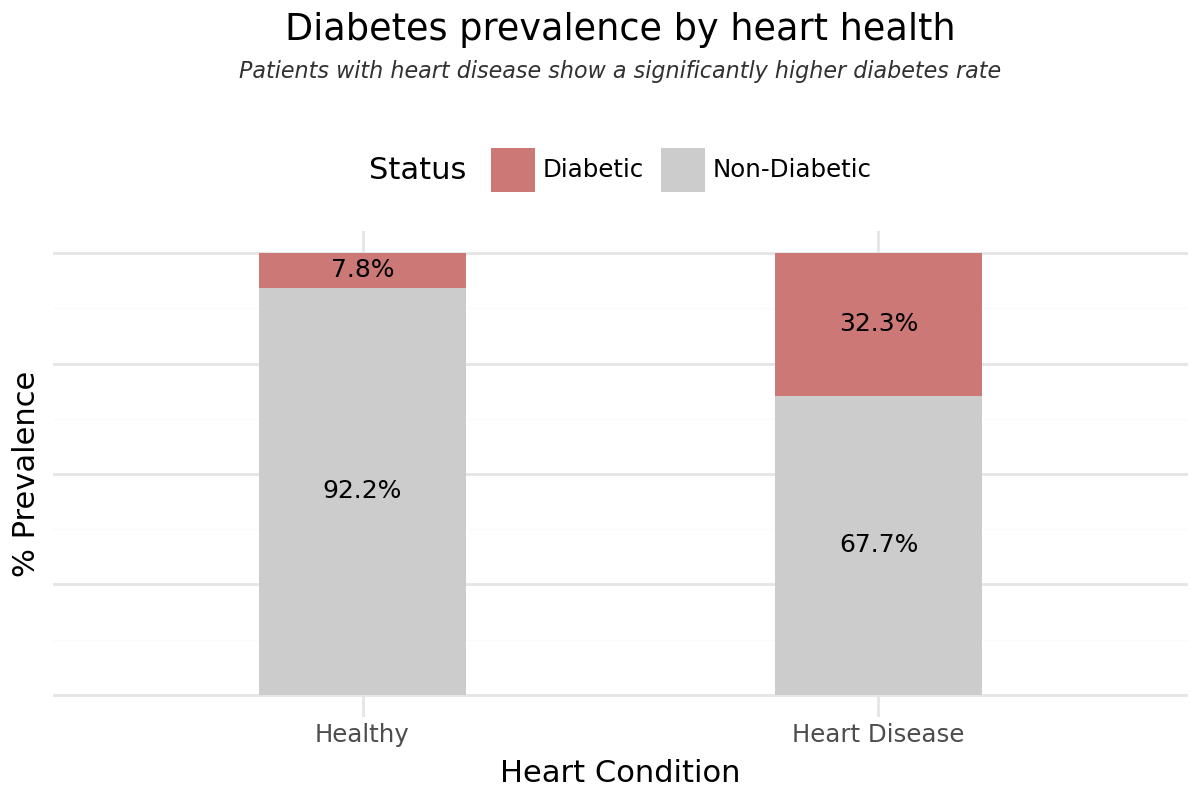

In [56]:
(ggplot(heart_dis, aes(x='reorder(heart_str,pct)', y='pct', fill='t_str'))
+ geom_col(position='stack',width=0.4)
+ geom_text(aes(label=heart_dis['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 0.5), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by heart health', 
       subtitle='Patients with heart disease show a significantly higher diabetes rate',
      fill='Status',
     x='Heart Condition', 
      y='% Prevalence')
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_y = element_blank(),
       axis_line_y = element_blank()))

In [57]:
# For only diabetic patients
heart_diabetic = heart_dis[heart_dis['t_str']=='Diabetic']
heart_diabetic

,heart_str,t_str,patient_count,total_cat,pct
0,Healthy,Diabetic,7215,92223,7.8
2,Heart Disease,Diabetic,1267,3923,32.3


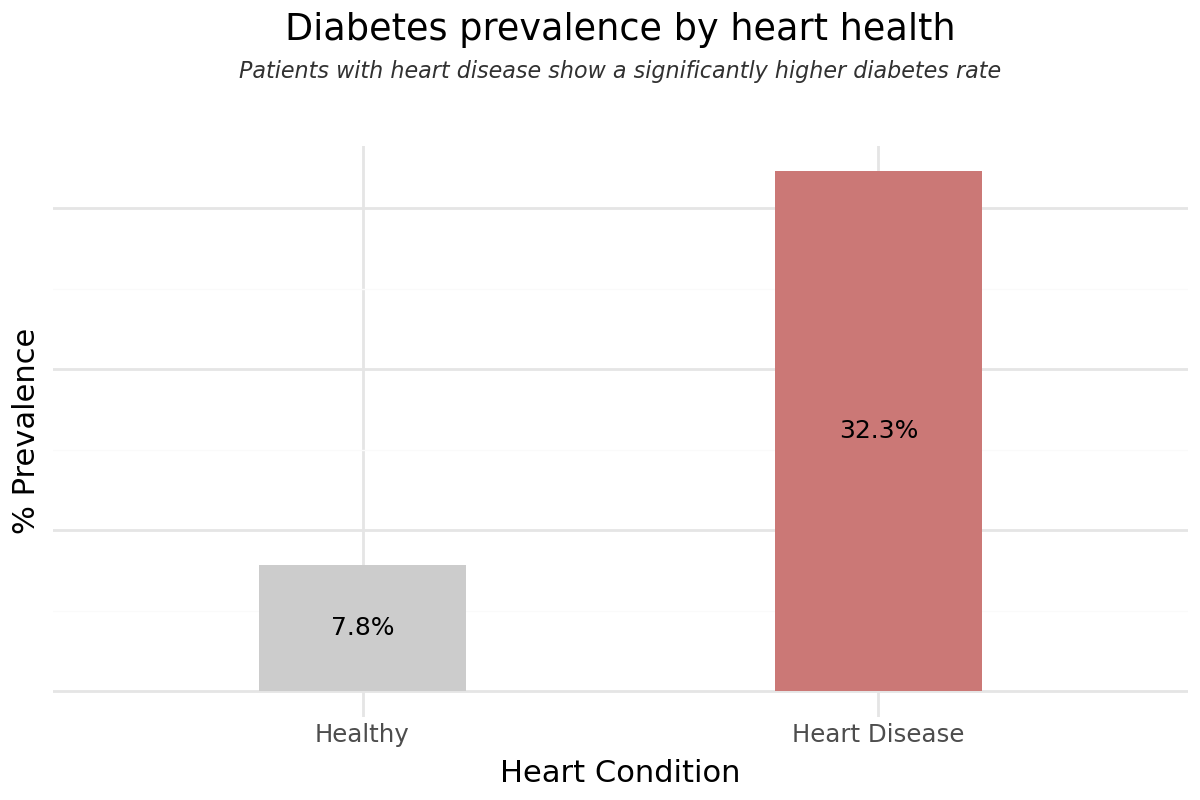

In [58]:
(ggplot(heart_diabetic, aes(x='reorder(heart_str,pct)', y='pct', fill='heart_str'))
+ geom_col(width=0.4, show_legend = False)
+ geom_text(aes(label=heart_diabetic['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 0.5), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by heart health', 
       subtitle='Patients with heart disease show a significantly higher diabetes rate',
      fill='Status',
     x='Heart Condition', 
      y='% Prevalence')
+ scale_fill_manual(values={'Heart Disease':'#cb7876', 'Healthy': '#cccccc'})
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_y = element_blank(),
       axis_line_y = element_blank()))

---
✅Does smoking status influence diabetes prevalence?

In [59]:
smoking_his_dis = diabetes[['t_str','smoking_history']].value_counts().reset_index(name='patient_count')
smoking_his_dis

,t_str,smoking_history,patient_count
0,Non-Diabetic,No Info,31442
1,Non-Diabetic,never,31061
2,Non-Diabetic,current,8249
3,Non-Diabetic,former,7709
4,Non-Diabetic,not current,5677
5,Non-Diabetic,ever,3526
6,Diabetic,never,3337
7,Diabetic,former,1590
8,Diabetic,No Info,1445
9,Diabetic,current,948


In [60]:
smoking_his_dis['total_cat'] =smoking_his_dis.groupby('smoking_history')['patient_count'].transform('sum')
smoking_his_dis

,t_str,smoking_history,patient_count,total_cat
0,Non-Diabetic,No Info,31442,32887
1,Non-Diabetic,never,31061,34398
2,Non-Diabetic,current,8249,9197
3,Non-Diabetic,former,7709,9299
4,Non-Diabetic,not current,5677,6367
5,Non-Diabetic,ever,3526,3998
6,Diabetic,never,3337,34398
7,Diabetic,former,1590,9299
8,Diabetic,No Info,1445,32887
9,Diabetic,current,948,9197


In [61]:
smoking_his_dis['pct'] = (smoking_his_dis['patient_count']/smoking_his_dis['total_cat']*100).round(1)
smoking_his_dis

,t_str,smoking_history,patient_count,total_cat,pct
0,Non-Diabetic,No Info,31442,32887,95.6
1,Non-Diabetic,never,31061,34398,90.3
2,Non-Diabetic,current,8249,9197,89.7
3,Non-Diabetic,former,7709,9299,82.9
4,Non-Diabetic,not current,5677,6367,89.2
5,Non-Diabetic,ever,3526,3998,88.2
6,Diabetic,never,3337,34398,9.7
7,Diabetic,former,1590,9299,17.1
8,Diabetic,No Info,1445,32887,4.4
9,Diabetic,current,948,9197,10.3


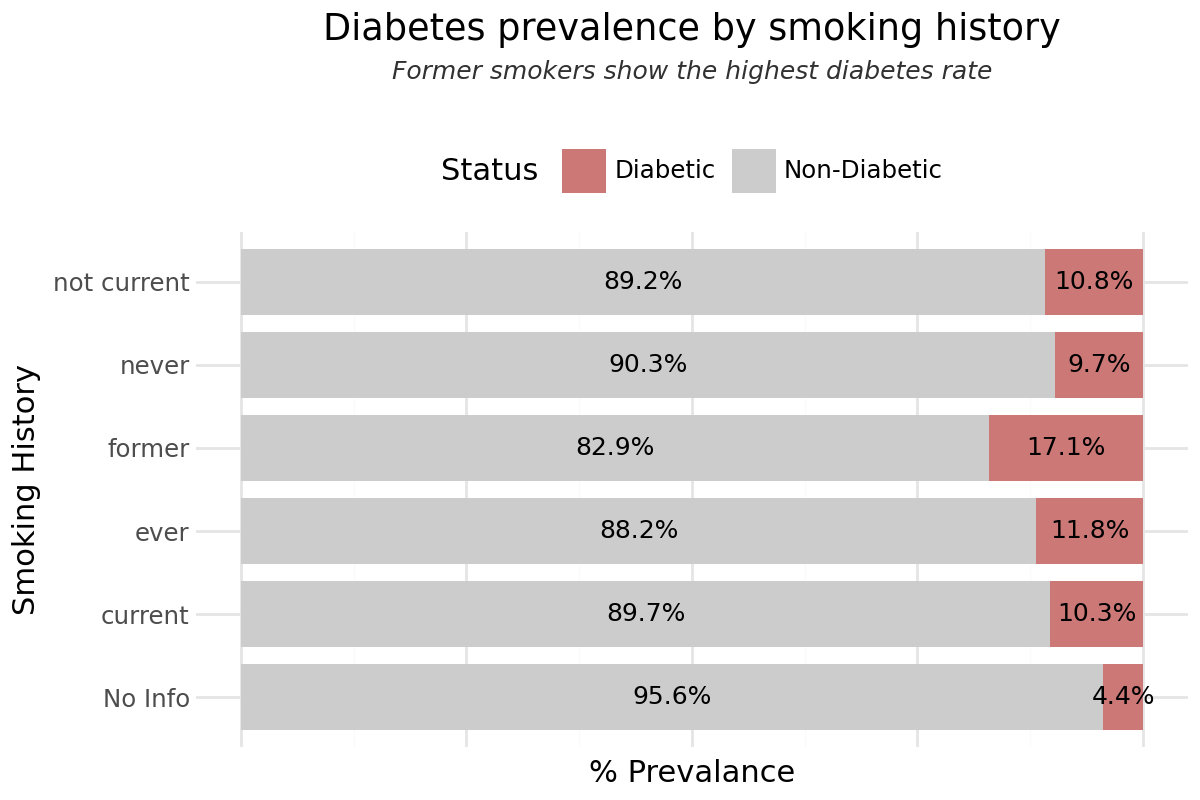

In [62]:
(ggplot(smoking_his_dis, aes(x='reorder(smoking_history,pct)', y='pct', fill='t_str'))
+ geom_col(position='stack',width=0.8)
+ coord_flip()
+ geom_text(aes(label=smoking_his_dis['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 0.5), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by smoking history',  subtitle='Former smokers show the highest diabetes rate',
      fill='Status',
     x='Smoking History', 
      y='% Prevalance')
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
+ theme( plot_subtitle=element_text(size=9,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_x = element_blank(),
       axis_line_x = element_blank(),
       axis_line_y=element_blank()))

In [63]:
diabetic_smokers = smoking_his_dis[smoking_his_dis['t_str']=='Diabetic']
diabetic_smokers

,t_str,smoking_history,patient_count,total_cat,pct
6,Diabetic,never,3337,34398,9.7
7,Diabetic,former,1590,9299,17.1
8,Diabetic,No Info,1445,32887,4.4
9,Diabetic,current,948,9197,10.3
10,Diabetic,not current,690,6367,10.8
11,Diabetic,ever,472,3998,11.8


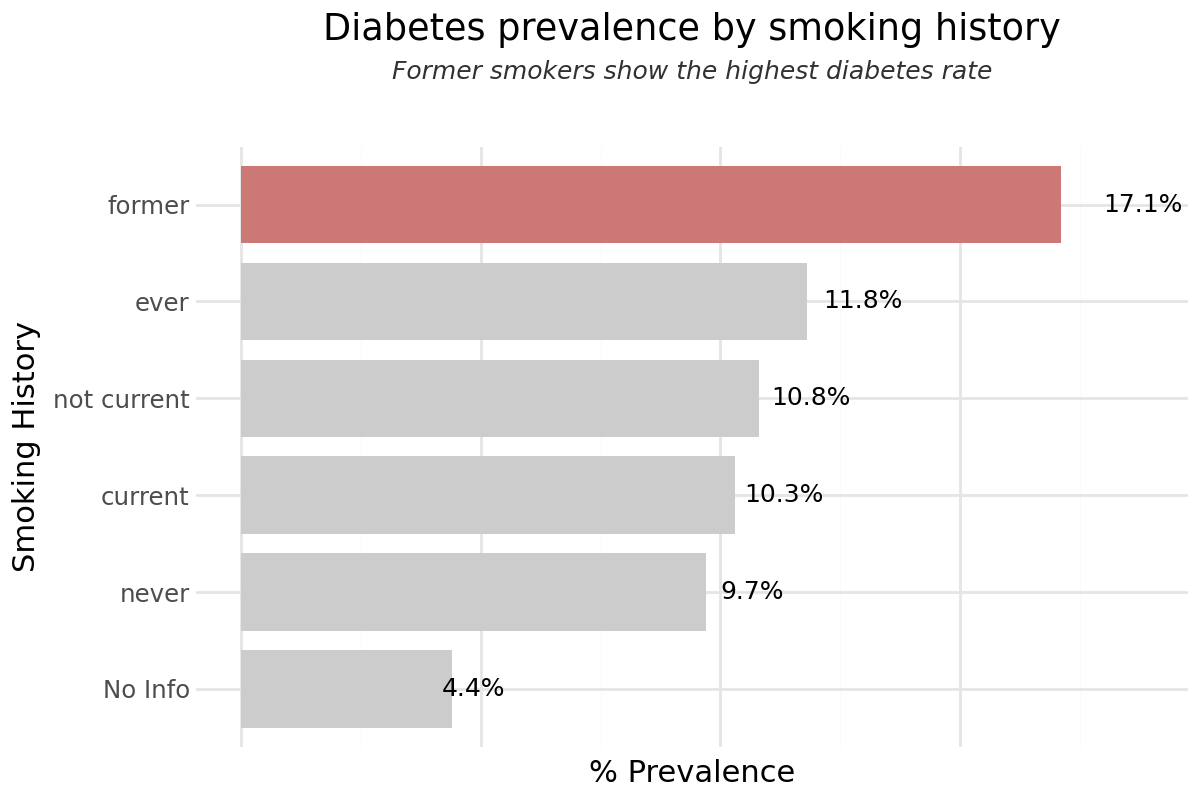

In [64]:
(ggplot(diabetic_smokers, aes(x='reorder(smoking_history,pct)', y='pct', fill='smoking_history'))
+ geom_col(width=0.8, show_legend = False)
+ coord_flip()
+ geom_text(aes(label=diabetic_smokers['pct'].astype(str) + "%"),  
            position = position_stack(vjust = 1.1), size = 9)
+ theme_minimal()
+ labs(title='Diabetes prevalence by smoking history', subtitle='Former smokers show the highest diabetes rate',
      fill='Status',
     x='Smoking History', 
      y='% Prevalence')
+ scale_fill_manual(values={'former':'#cb7876', 'No Info': '#cccccc', 'never': '#cccccc','current': '#cccccc', 
                            'not current': '#cccccc','ever': '#cccccc'})
+ theme(plot_subtitle=element_text(size=9,style='italic',color='#313131', ha='center',margin={'b':15}),
        figure_size=(6,4), 
       legend_position='top',
       axis_text_x = element_blank(),
       axis_line_y = element_blank()))

---
✅How does BMI differ between diabetic and non-diabetic patients?

In [65]:
bmi_avg = diabetes.groupby('t_str')['bmi'].mean().reset_index(name='avg_bmi').round(2)
bmi_avg

,t_str,avg_bmi
0,Diabetic,32.00
1,Non-Diabetic,26.87


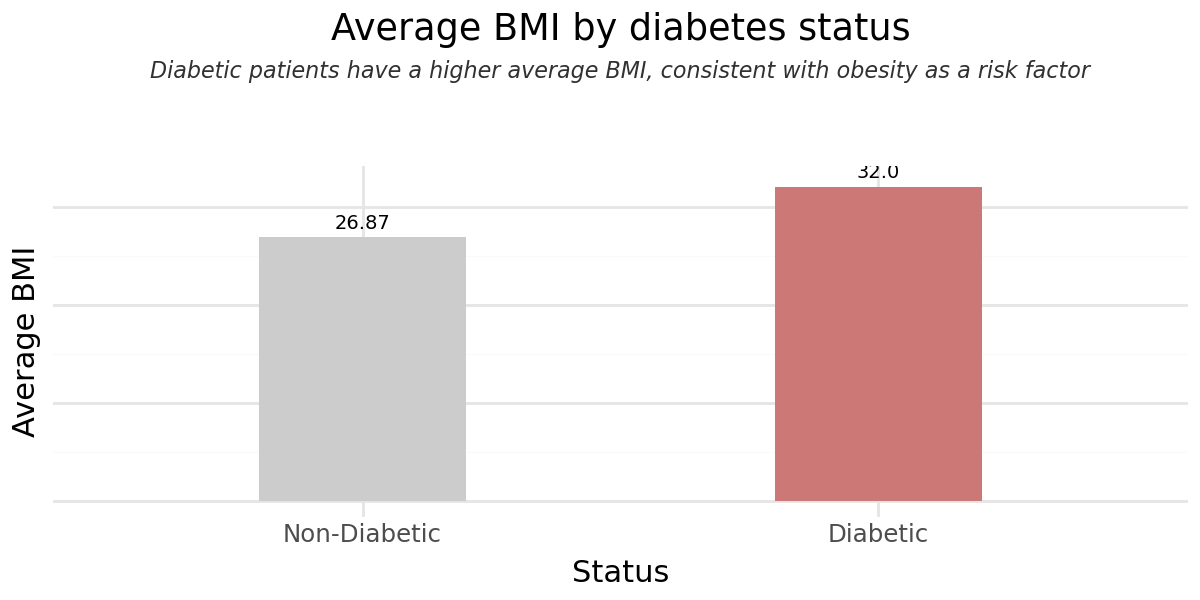

In [66]:
(ggplot(bmi_avg, aes(x='reorder(t_str,avg_bmi)', y='avg_bmi', fill='t_str'))
+ geom_col(width=0.4, show_legend=False)
+ geom_text(aes(label = 'avg_bmi'),
            va='bottom',
            nudge_y=0.5,
            size = 7)
+ theme_minimal()
+ labs(title='Average BMI by diabetes status', 
       subtitle='Diabetic patients have a higher average BMI, consistent with obesity as a risk factor', 
     x='Status', 
     y='Average BMI')
+ theme( plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        axis_line_y = element_blank(),
        axis_text_y = element_blank(),
        axis_ticks_y = element_blank(),
        axis_line_x = element_blank(),
        figure_size=(6,3))
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
)

---
✅How does HbA1c level differ between diabetic and non-diabetic patients? 

In [67]:
avg_hb = diabetes.groupby('t_str')['HbA1c_level'].mean().reset_index(name='avg_hb').round(2)
avg_hb

,t_str,avg_hb
0,Diabetic,6.93
1,Non-Diabetic,5.40


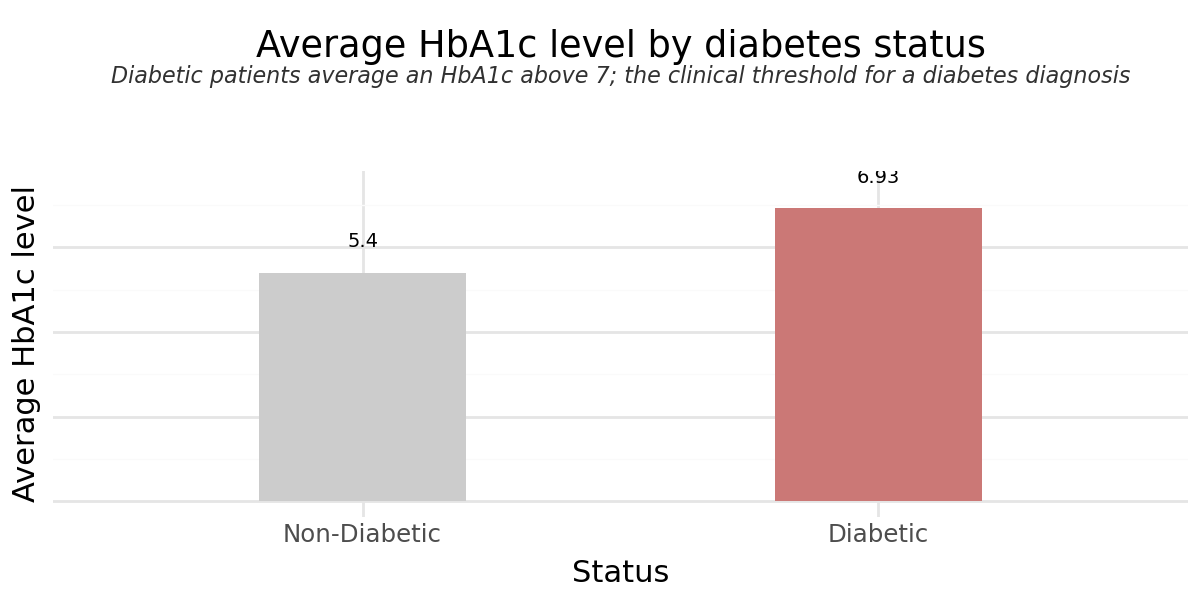

In [68]:
(ggplot(avg_hb, aes(x='reorder(t_str,avg_hb)', y='avg_hb', fill='t_str'))
+ geom_col(width=0.4, show_legend=False)
+ geom_text(aes(label = 'avg_hb'),
            va='bottom',
            nudge_y=0.5,
            size = 7)
+ theme_minimal()
+ labs(title='Average HbA1c level by diabetes status', 
       subtitle='Diabetic patients average an HbA1c above 7; the clinical threshold for a diabetes diagnosis',
     x='Status', 
     y='Average HbA1c level')
+ theme(plot_title=element_text(ha='center',margin={'t':3}),
        plot_subtitle=element_text(size=8,style='italic',color='#313131', ha='center',margin={'b':15}),
        axis_line_y = element_blank(),
        axis_text_y = element_blank(),
        axis_ticks_y = element_blank(),
        axis_line_x = element_blank(),
        figure_size=(6,3))
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
)

---
✅ Does blood glucose levels differ between diabetic and non diabetic patients?

In [69]:
avg_bg = diabetes.groupby('t_str')['blood_glucose_level'].mean().reset_index(name='avg_blood_glucose').round(2)
avg_bg

,t_str,avg_blood_glucose
0,Diabetic,194.03
1,Non-Diabetic,132.82


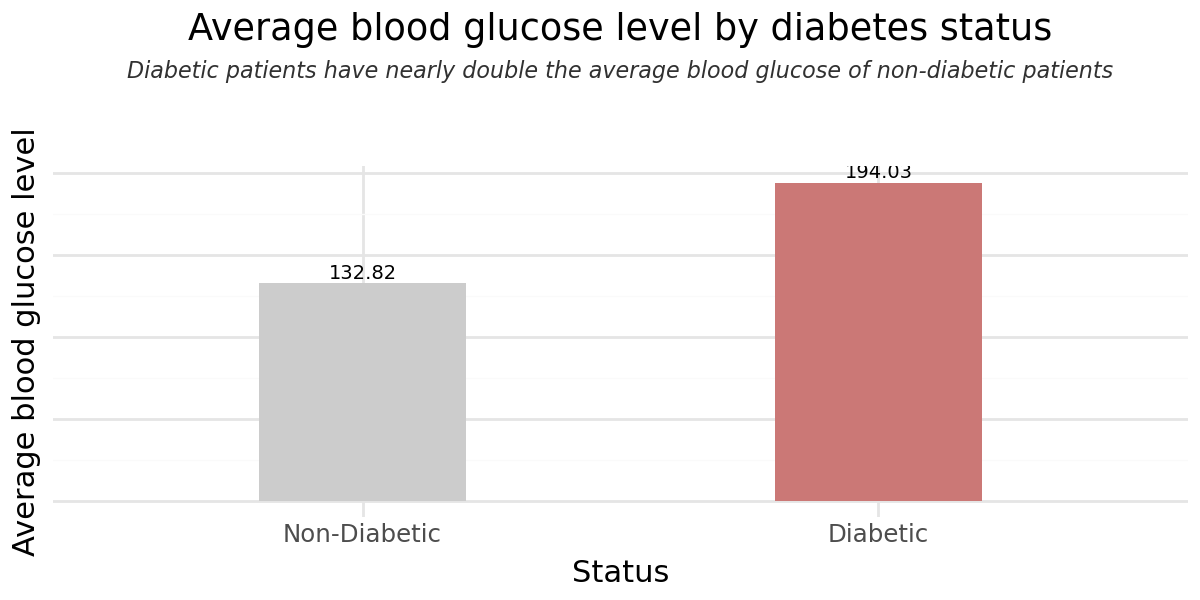

In [70]:
(ggplot(avg_bg, aes(x='reorder(t_str,avg_blood_glucose)', y='avg_blood_glucose', fill='t_str'))
+ geom_col(width=0.4, show_legend=False)
+ geom_text(aes(label = 'avg_blood_glucose'),
            va='bottom',
            nudge_y=0.5,
            size = 7)
+ theme_minimal()
+ labs(title='Average blood glucose level by diabetes status', 
       subtitle='Diabetic patients have nearly double the average blood glucose of non-diabetic patients',
     x='Status', 
     y='Average blood glucose level')
+ theme(plot_subtitle=element_text(size=8,
                                   style='italic',
                                   color='#313131', 
                                   ha='center',
                                   margin={'b':15}),
        axis_line_y = element_blank(),
        axis_text_y = element_blank(),
        axis_ticks_y = element_blank(),
        axis_line_x = element_blank(),
        figure_size=(6,3))
+ scale_fill_manual(values={'Diabetic':'#cb7876', 'Non-Diabetic': '#cccccc'})
)

---
✅Which factors show the strongest relationship with diabetes?  (Correlation matrix)

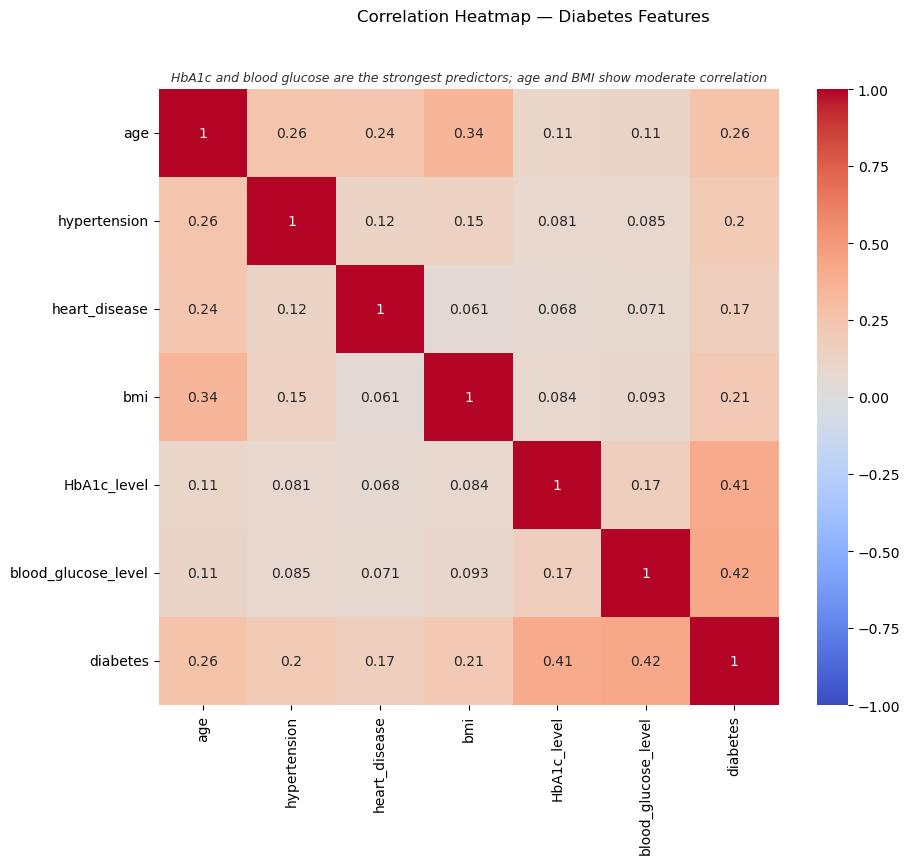

In [71]:
plt.figure(figsize=(10, 8))
sns.heatmap(diabetes.corr(numeric_only=True), vmin=-1, vmax=1, annot=True, cmap='coolwarm')
plt.suptitle('Correlation Heatmap — Diabetes Features', fontsize=12,y=0.98)
plt.title('HbA1c and blood glucose are the strongest predictors; age and BMI show moderate correlation', 
          fontsize=9, 
          color='#313131',
          style='italic')
plt.show()

---
✅What combinations of risk factors characterize diabetic patients?
Something like this(older + high BMI + high HbA1 = Diabetes)

In [72]:
diabetic_only = diabetes[diabetes['diabetes'] == 1][['age', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'blood_glucose_level']].mean().round(2).reset_index(name='mean')
diabetic_only

,index,mean
0,age,60.93
1,bmi,32.00
2,hypertension,0.25
3,heart_disease,0.15
4,HbA1c_level,6.93
5,blood_glucose_level,194.03


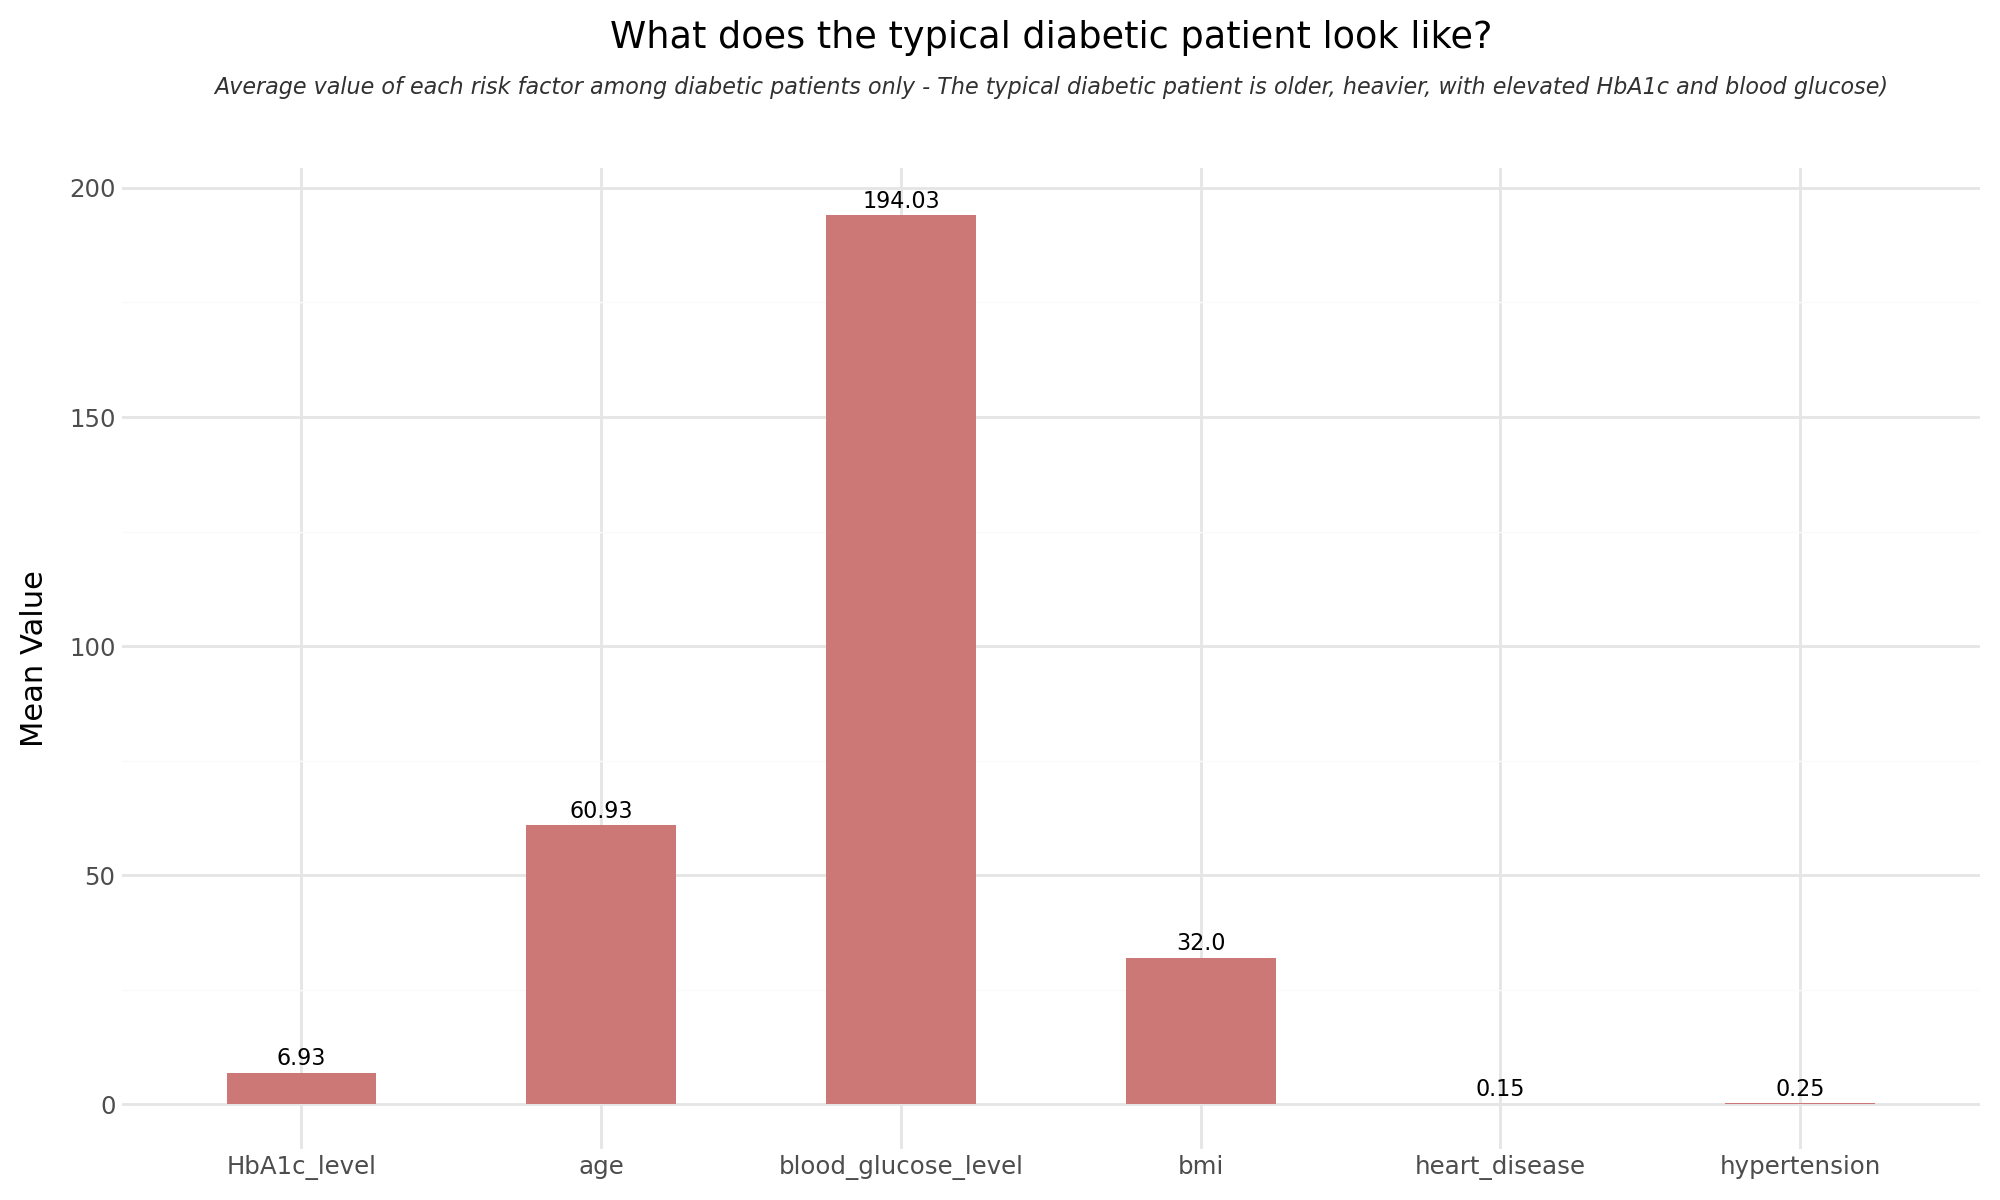

In [73]:
chart2=(ggplot(diabetic_only, aes('index', 'mean'))
+ geom_col(fill='#cb7876', width=0.5)
+ geom_text(aes(label = 'mean'),
            va='bottom',
            nudge_y=0.5,
            size = 8)
+ theme_minimal()
+ theme(figure_size=(10, 6),
        plot_subtitle=element_text(size=8,
                                   style='italic',
                                   color='#313131', 
                                   ha='center',
                                   margin={'b':15}))
+ labs(title='What does the typical diabetic patient look like?',
       subtitle='Average value of each risk factor among diabetic patients only - The typical diabetic patient is older, heavier, with elevated HbA1c and blood glucose)',
       x='', y='Mean Value')
)
chart2

In [74]:
diabetes[diabetes['diabetes']==1][['age','bmi', 'hypertension', 'HbA1c_level','blood_glucose_level']].describe().round(2)

,age,bmi,hypertension,HbA1c_level,blood_glucose_level
count,8482.00,8482.00,8482.00,8482.00,8482.00
mean,60.93,32.00,0.25,6.93,194.03
std,14.55,7.56,0.43,1.08,58.63
min,3.00,10.98,0.00,5.70,126.00
25%,52.00,27.32,0.00,6.10,145.00
50%,62.00,29.98,0.00,6.60,160.00
75%,72.00,35.94,0.00,7.50,240.00
max,80.00,88.72,1.00,9.00,300.00


---
# SECTION 2
### ML
#### LOGISTIC REGRESSION

In [75]:
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group,t_str,age_band,hyp_str,heart_str
0,Female,80.0,0,1,never,25.19,6.6,140,0,Older Adults,Non-Diabetic,60+,Non-hypertensive,Heart Disease
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Middle Age,Non-Diabetic,50-59,Non-hypertensive,Healthy
2,Male,28.0,0,0,never,27.32,5.7,158,0,Young Adults,Non-Diabetic,<30,Non-hypertensive,Healthy
3,Female,36.0,0,0,current,23.45,5.0,155,0,Young Adults,Non-Diabetic,30-39,Non-hypertensive,Healthy
4,Male,76.0,1,1,current,20.14,4.8,155,0,Older Adults,Non-Diabetic,60+,Hypertensive,Heart Disease


In [76]:
diabetes.dtypes

gender                   object
age                     float64
hypertension              int64
heart_disease             int64
smoking_history          object
bmi                     float64
HbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
age_group              category
t_str                    object
age_band               category
hyp_str                  object
heart_str                object
dtype: object

In [77]:
# dropping the string columns created for vizualization
diabetes2=diabetes.drop(columns=['t_str', 'hyp_str','heart_str', 'age_band'])
diabetes2

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group
0,Female,80.0,0,1,never,25.19,6.6,140,0,Older Adults
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Middle Age
2,Male,28.0,0,0,never,27.32,5.7,158,0,Young Adults
3,Female,36.0,0,0,current,23.45,5.0,155,0,Young Adults
4,Male,76.0,1,1,current,20.14,4.8,155,0,Older Adults
...,...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0,Young Adults
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0,Children
99997,Male,66.0,0,0,former,27.83,5.7,155,0,Older Adults
99998,Female,24.0,0,0,never,35.42,4.0,100,0,Young Adults


#### Preparing data for modeling

In [78]:
# X = all columns except target
# y = just the target column

# encoding gender, smoking history and age_group column
diabetes2['age_group'] = diabetes2['age_group'].astype(str)

x = pd.get_dummies(diabetes2.drop(['diabetes'],axis=1),
                  columns=['gender','smoking_history','age_group'], 
                  drop_first=True, 
                  dtype=int)
                   
y = diabetes2['diabetes']

print(x.head())
print(y.head())

    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   gender_Male  gender_Other  smoking_history_current  smoking_history_ever  \
0            0             0                        0                     0   
1            0             0                        0                     0   
2            1             0                        0                     0   
3            0             0                        1                     0   
4            1             0                        1                     0   

   smoking_history_former  smoking_his

In [79]:
# splitting the data into 3: 
                           # 60% for training, 
                          # 20% for validation and 
                          # 20% for testing
# random_state=42 ensures same split every run

#first split into 2(one for test(x_test), the other half for training and validation(x_temp)
x_temp, x_test, y_temp, y_test = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y
)

#second split(spliting x_temp into training set and validation set)
x_train, x_val, y_train, y_val=train_test_split(x_temp,y_temp,test_size=0.25, random_state=42, stratify=y_temp)

print('Training set:', x_train.shape)
print('Validation set:', x_val.shape)
print('Test set:    ', x_test.shape)

Training set: (57687, 17)
Validation set: (19229, 17)
Test set:     (19230, 17)


##### NEXT STEP
Standardizing the dependent variables with StandardScaler because the Features are on completely different scales:

What StandardScaler Does  
 It rescales every feature so that:
* Mean = 0 (the average becomes zero)
* Standard deviation = 1 (the spread becomes 1)
* The formula: scaled_value = (original_value - mean) / std_deviation

The steps:
1. `fit()` on X_train → scaler learns the mean and std from training data
2. `transform()` on X_train → scales training data using those values
3. `transform()` on X_val → scales validating data gotten from the training  values
4. `transform()` on X_test → scales test data using the BEST values from validation
This way, the test data will be treated exactly like real unseen data would be.

ALWAYS fit the scaler on training data only, NEVER on test data. Because fitting means learning the mean and std of the data.
If the test data is included in the fit, the model has "seen" the test data indirectly, giving it falsely good results.

---

In [80]:
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Fit on training data ONLY 
x_train_scaled = scaler.fit_transform(x_train)

#transforming the validation and test data
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# Putting them back into a DataFrame so we can see column names
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_train_scaled_df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age_group_Children,age_group_Middle Age,age_group_Older Adults,age_group_Young Adults
0,1.255842,-0.290277,-0.205389,0.681906,-0.959659,-0.930541,1.180278,-0.012492,-0.324867,-0.206532,-0.329057,-0.743008,3.734276,-0.380331,-0.642675,2.108255,-0.713764
1,0.500283,-0.290277,-0.205389,-0.126267,0.905653,0.414007,-0.847258,-0.012492,-0.324867,-0.206532,3.038988,-0.743008,-0.267790,-0.380331,1.555996,-0.474326,-0.713764
2,1.211397,-0.290277,-0.205389,0.311062,-0.679862,-1.419468,1.180278,-0.012492,-0.324867,-0.206532,-0.329057,-0.743008,3.734276,-0.380331,-0.642675,2.108255,-0.713764
3,-1.771726,-0.290277,-0.205389,-1.184133,0.625856,-0.197151,1.180278,-0.012492,-0.324867,-0.206532,-0.329057,-0.743008,-0.267790,2.629291,-0.642675,-0.474326,-0.713764
4,1.166952,-0.290277,-0.205389,0.925688,0.998918,3.469799,1.180278,-0.012492,-0.324867,-0.206532,-0.329057,1.345880,-0.267790,-0.380331,-0.642675,2.108255,-0.713764


---
#### INTRODUCING THE MODEL TO THE DATASET USING THE TRAINING SET
Here the model learn the relationship between the features and diabetes

In [81]:
# MODEL1: Logistic Regression on standardised data
# Features: all features (scaled) | Data: X_train_scaled, y_train

model_diabetes = LogisticRegression()
model_diabetes.fit(x_train_scaled_df, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


##### Model Parameters from the learning
Intercept and Coefficients

In [82]:
# Raw coefficients 
coef_df = pd.DataFrame(model_diabetes.coef_.T,
    index=x_train_scaled_df.columns, columns=['Log Odds Coefficient'])

print('Raw Log Odds Coefficients:')
print(coef_df)

Raw Log Odds Coefficients:
                             Log Odds Coefficient
age                                      1.029493
hypertension                             0.212945
heart_disease                            0.156617
bmi                                      0.579499
HbA1c_level                              2.469518
blood_glucose_level                      1.370886
gender_Male                              0.135386
gender_Other                            -0.059430
smoking_history_current                  0.193886
smoking_history_ever                     0.110361
smoking_history_former                   0.143731
smoking_history_never                    0.249827
smoking_history_not current              0.127829
age_group_Children                       0.081978
age_group_Middle Age                     0.126987
age_group_Older Adults                   0.055229
age_group_Young Adults                  -0.002544



###### Model Parameters: Intercept and Coefficients
* The coefficients are in LOG ODDS, not plain numbers.
* Odds = probability of event happening / probability of event NOT happening
* Log Odds = log(odds) This is hard to interpret directly.
* so convert log odds to Odds Ratios using np.exp() (the exponential function).


In [83]:
odds_df = pd.DataFrame(
    np.exp(model_diabetes.coef_),
    columns=x_train_scaled_df.columns).T

#putting them in a dataframe
odds_df.columns = ['Odds Ratio']
odds_df = odds_df.sort_values('Odds Ratio', ascending=False)

print('Odds Ratios (sorted from highest to lowest):')
print(odds_df.round(3))

Odds Ratios (sorted from highest to lowest):
                             Odds Ratio
HbA1c_level                      11.817
blood_glucose_level               3.939
age                               2.800
bmi                               1.785
smoking_history_never             1.284
hypertension                      1.237
smoking_history_current           1.214
heart_disease                     1.170
smoking_history_former            1.155
gender_Male                       1.145
smoking_history_not current       1.136
age_group_Middle Age              1.135
smoking_history_ever              1.117
age_group_Children                1.085
age_group_Older Adults            1.057
age_group_Young Adults            0.997
gender_Other                      0.942


#### Interpretation of the Odds Ratios
* Odds ratio > 1 → higher value of this feature → MORE likely to be diabetic  
* Odds ratio < 1 → higher value of this feature → LESS likely to be diabetic  
* Odds ratio ≈ 1 → this feature has little to no effect on the prediction  

#### The Percentage Interpretation Using the above Results
Using the % formula: (odds ratio - 1) × 100

 **HbA1c_level - Odds Ratio: 11.817**  
`11.817 → (11.817 - 1) × 100 = 1,082%`  
→ A 1 unit increase in HbA1c multiplies the odds of being diabetic by 11.817  
→ i.e., 1,082% increase in odds of being diabetic  
→ The single strongest predictor in this model  

**blood_glucose_level - Odds Ratio: 3.939**  
`3.939 → (3.939 - 1) × 100 = 294%`  
→ A 1 unit increase in blood glucose multiplies the odds of being diabetic by 3.939  
→ i.e., 294% increase in odds of being diabetic  

 **age - Odds Ratio: 2.800**  
`2.800 → (1 - 2.800) × 100 = 180%`  
→ A 1 unit increase in age multiplies the odds of being diabetic by 2.800  
→ i.e., 180% increase in odds of being diabetic

**bmi - Odds Ratio: 1.785**  
→ A 1 unit increase in BMI multiplies the odds of being diabetic by 1.785  
→ i.e., 79% increase in odds of being diabetic

**gender_Other - Odds Ratio: 0.942**  
`0.942 → (1 - 0.942) × 100 = 6% decrease`  
→ A 1-unit increase multiplies the odds of being diabetic by 0.942  
→ i.e., 6% decrease in odds of being diabetic  
→ The only feature associated with lower diabetes odds in this model


In [84]:
# Splitting into two groups to make interpretation easier

print(' FEATURES THAT INCREASE ODDS OF BEING Diabetic (Odds Ratio > 1) ')
print(odds_df[odds_df['Odds Ratio'] > 1].round(3))
print()
print(' FEATURES THAT DECREASE ODDS OF BEING Diabetic (Odds Ratio < 1) ')
print(odds_df[odds_df['Odds Ratio'] < 1].sort_values('Odds Ratio').round(3))

 FEATURES THAT INCREASE ODDS OF BEING Diabetic (Odds Ratio > 1) 
                             Odds Ratio
HbA1c_level                      11.817
blood_glucose_level               3.939
age                               2.800
bmi                               1.785
smoking_history_never             1.284
hypertension                      1.237
smoking_history_current           1.214
heart_disease                     1.170
smoking_history_former            1.155
gender_Male                       1.145
smoking_history_not current       1.136
age_group_Middle Age              1.135
smoking_history_ever              1.117
age_group_Children                1.085
age_group_Older Adults            1.057

 FEATURES THAT DECREASE ODDS OF BEING Diabetic (Odds Ratio < 1) 
                        Odds Ratio
gender_Other                 0.942
age_group_Young Adults       0.997


---
#### PREDICTING ON THE VALIDATION SET WITH THE MODEL EXPOSED TO TRAINING SET
Predicting on the validation data

In [85]:
x_val_scaled_df = pd.DataFrame(x_val_scaled, columns=x_val.columns)

# Predict on scaled Val data
y_val_pred = model_diabetes.predict(x_val_scaled_df)

# Evaluate
print(' VALIDATION DATA EVALUATION ')
print(metrics.classification_report(y_val, y_val_pred, target_names=['Non-Diabetic', 'Diabetic']))

y_val_prob = model_diabetes.predict_proba(x_val_scaled_df)[:,1]
roc_auc = roc_auc_score(y_val, y_val_prob)
print(f'ROC-AUC SCORE:{roc_auc:.4f}')

 VALIDATION DATA EVALUATION 
              precision    recall  f1-score   support

Non-Diabetic       0.97      0.99      0.98     17533
    Diabetic       0.86      0.63      0.73      1696

    accuracy                           0.96     19229
   macro avg       0.91      0.81      0.85     19229
weighted avg       0.96      0.96      0.96     19229

ROC-AUC SCORE:0.9604


In [86]:
print('ACCURACY')
print(model_diabetes.score(x_train_scaled_df, y_train))
print(model_diabetes.score(x_val_scaled_df, y_val))

ACCURACY
0.9587082011545062
0.958344167663425


#### Model Evaluation

**Accuracy - 0.96 (96%)**  
96% of all predictions made by the model were correct.

**Precision (Diabetic) - 0.86 (86%)**  
When the model predicts an individual is "Diabetic", it is correct 86% of the time.  

**Recall / Sensitivity (Diabetic) - 0.63 (63%)**  
Out of all individuals who are actually diabetic, the model successfully caught 63% of them.   

**ROC-AUC Score - 0.9604**  
The model has a 96.04% ability to distinguish between the diabetic and non-diabetic classes across various thresholds,   
showing strong overall discriminative power despite the class imbalance.

**Conclusion: Class Imbalance**    
The validation report shows a recall of 63% for the diabetic class compared to 99% for non-diabetic patients.  
This is explained by the significant class imbalance in the dataset   
17,533 non-diabetic vs 1,696 diabetic patients in the validation set alone (roughly 10:1 ratio).    
A model that missed 37% of actual diabetic patients is clinically unacceptable.  

**To address this, class_weight='balanced' will be applied to penalise the model more heavily for missing diabetic cases.**

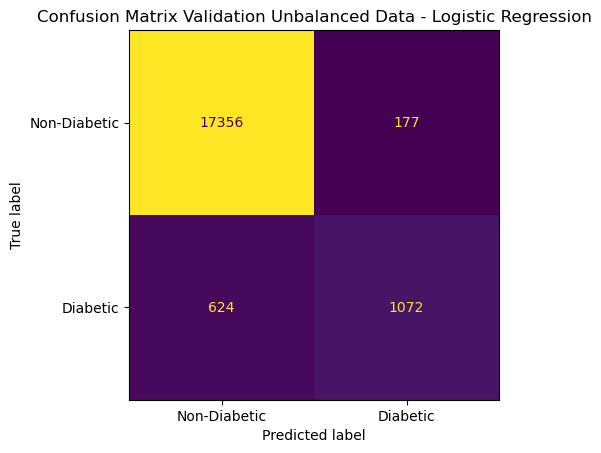

In [87]:
# Confusion Matrix for validation data
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, display_labels=['Non-Diabetic', 'Diabetic'],
                                       colorbar=False)
plt.title('Confusion Matrix Validation Unbalanced Data - Logistic Regression')
plt.show()

| | Predicted: Non-Diabetic | Predicted: Diabetic |
|---|---|---|
| **Actual: Non-Diabetic**   | **True Negative** ✅  | **False Positive** ⚠️ |
| **Actual: Diabetic**       | **False Negative** ❌ | **True Positive** ✅  |

**What each outcome means:**
- `17356` **True Negative** — Model said not diabetic, they are not diabetic.(✅ Healthy patient correctly identified as healthy)
- `177`  **False Positive** — Model said diabetic, but they are not. Patient gets unnecessary further tests.(⚠️ Healthy patient wrongly flagged as diabetic )
- `624`  **False Negative** — Model said not diabetic, but they ARE. Patient sent home undiagnosed.(❌ Diabetic patient missed
  most dangerous outcome)
- `1072` **True Positive** — Model correctly predicted them as diabetic( ✅ Diabetic patient correctly identified )
> **recall** is the priority metric, it directly measures how well the model avoids False Negatives.

---
##### INTRODUCING BALANCE

In [88]:
model_diabetes2 = LogisticRegression(class_weight ='balanced',
                                   max_iter=1000,
                                   random_state=42)
model_diabetes2.fit(x_train_scaled_df, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [89]:
# RePredicting with the validation set
y_val_pred2 = model_diabetes2.predict(x_val_scaled_df)

# Evaluate
print(' SECOND VALIDATION DATA EVALUATION ')
print(metrics.classification_report(y_val, y_val_pred2, target_names=['Non-Diabetic', 'Diabetic']))

y_val_prob = model_diabetes2.predict_proba(x_val_scaled_df)[:,1]
roc_auc = roc_auc_score(y_val, y_val_prob)
print(f'ROC-AUC SCORE:{roc_auc:.4f}')

 SECOND VALIDATION DATA EVALUATION 
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.88      0.93     17533
    Diabetic       0.42      0.88      0.57      1696

    accuracy                           0.88     19229
   macro avg       0.70      0.88      0.75     19229
weighted avg       0.94      0.88      0.90     19229

ROC-AUC SCORE:0.9606


#### Model Evaluation

**Accuracy - 0.88 (88%)**  
88% of all predictions made by the model were correct.

**Precision (Diabetic) - 0.42 (42%)**  
When the model predicts an individual is "Diabetic", it is correct 42% of the time.  
This is a high number of false positives.

**Recall / Sensitivity (Diabetic) - 0.88 (88%)**  
Out of all individuals who are actually diabetic, the model successfully caught 88% of them.   
Only 12% of actual diabetic cases were missed (false negatives).

**F1-Score (Diabetic) - 0.57 (57%)**  
The balance between precision (42%) and recall (88%).

**ROC-AUC Score - 0.9606**  
The model has a 96.06% ability to distinguish between the diabetic and non-diabetic classes across various thresholds,   
showing strong overall discriminative power despite the class imbalance.

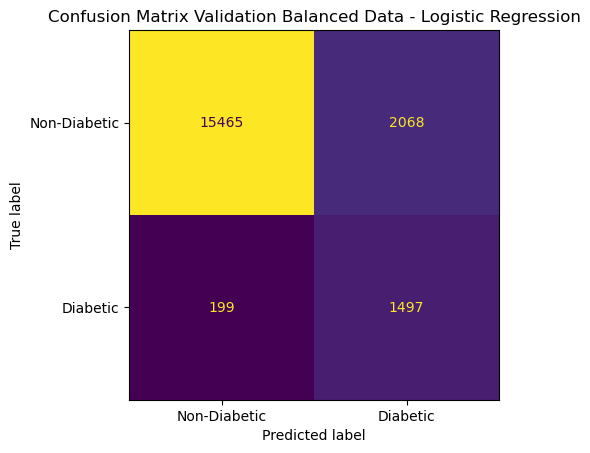

In [90]:
# Confusion Matrix for validation data
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred2, display_labels=['Non-Diabetic', 'Diabetic'],
                                       colorbar=False)
plt.title('Confusion Matrix Validation Balanced Data - Logistic Regression')
plt.show()

| | Predicted: Non-Diabetic | Predicted: Diabetic |
|---|---|---|
| **Actual: Non-Diabetic**   | **True Negative** ✅  | **False Positive** ⚠️ |
| **Actual: Diabetic**       | **False Negative** ❌ | **True Positive** ✅  |

**What each outcome means:**
- `15465` **True Negative** — Model said not diabetic, they are not diabetic.(✅ Healthy patient correctly identified as healthy)
- `2068`  **False Positive** — Model said diabetic, but they are not. Patient gets unnecessary further tests.(⚠️ Healthy patient wrongly flagged as diabetic )
- `199`  **False Negative** — Model said not diabetic, but they ARE. Patient sent home undiagnosed.(❌ Diabetic patient missed
  most dangerous outcome)
- `1497` **True Positive** — Model correctly predicted them as diabetic( ✅ Diabetic patient correctly identified )
> **recall** is the priority metric, it directly measures how well the model avoids False Negatives.

---
#### RANDOM FOREST

In [91]:
print('INDEPENDENT VARIABLES')
print(x)
print('TARGET VARIABLES')
print(y)

INDEPENDENT VARIABLES
        age  hypertension  heart_disease    bmi  HbA1c_level  \
0      80.0             0              1  25.19          6.6   
1      54.0             0              0  27.32          6.6   
2      28.0             0              0  27.32          5.7   
3      36.0             0              0  23.45          5.0   
4      76.0             1              1  20.14          4.8   
...     ...           ...            ...    ...          ...   
99994  36.0             0              0  24.60          4.8   
99996   2.0             0              0  17.37          6.5   
99997  66.0             0              0  27.83          5.7   
99998  24.0             0              0  35.42          4.0   
99999  57.0             0              0  22.43          6.6   

       blood_glucose_level  gender_Male  gender_Other  \
0                      140            0             0   
1                       80            0             0   
2                      158            

In [92]:
y.dtype

dtype('int64')

In [93]:
# splitting the data into 3: 
                           # 60% for training, 
                          # 20% for validation and 
                          # 20% for testing
# random_state=42 ensures same split every run

#first split into 2(one for test(x_test), the other half for training and validation(x_temp)
x_temp2, x_test2, y_temp2, y_test2 = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y
)

#second split(spliting x_temp into training set and validation set)
x_train2, x_val2, y_train2, y_val2=train_test_split(x_temp2,y_temp2,test_size=0.25, random_state=42, stratify=y_temp)

print('Training set:', x_train.shape)
print('Validation set:', x_val.shape)
print('Test set:    ', x_test.shape)

Training set: (57687, 17)
Validation set: (19229, 17)
Test set:     (19230, 17)


#### Check Class Balance

In [94]:
from collections import Counter

print(Counter(y))
print('Y Train')
print(Counter(y_train))
print('Y Val')
print(Counter(y_val))
print('Y Test')
print(Counter(y_test))

Counter({0: 87664, 1: 8482})
Y Train
Counter({0: 52597, 1: 5090})
Y Val
Counter({0: 17533, 1: 1696})
Y Test
Counter({0: 17534, 1: 1696})


#### Model 3  RANDOM FOREST

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, classification_report

#### CROSS VALIDATION
Checking the reliability and consistency of the model

In [96]:
rf_model = RandomForestClassifier(random_state=42, 
                                  class_weight="balanced")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_validate(rf_model, x_train_scaled_df, y_train, cv = cv,
    scoring = ["accuracy", "precision", "recall", "f1", "precision_weighted", "f1_weighted"]
)

rf_scores

{'fit_time': array([14.59670877, 13.11527872, 13.86718583, 14.30845737, 14.88250589]),
 'score_time': array([0.58520484, 0.61183524, 0.69585967, 0.56043005, 0.51806402]),
 'test_accuracy': array([0.97018547, 0.96767204, 0.96775592, 0.97018289, 0.9681893 ]),
 'test_precision': array([0.93880208, 0.93997271, 0.94986072, 0.95788043, 0.95780591]),
 'test_recall': array([0.70825147, 0.67681729, 0.66994106, 0.69253438, 0.66895874]),
 'test_f1': array([0.80739082, 0.78697887, 0.78571429, 0.80387685, 0.78773858]),
 'test_precision_weighted': array([0.96945698, 0.96694142, 0.9672597 , 0.96986169, 0.96789486]),
 'test_f1_weighted': array([0.96827384, 0.96525715, 0.96519652, 0.96798316, 0.96559392])}

In [97]:
print("Mean accuracy:",           rf_scores['test_accuracy'].mean())
print("Mean precision:",          rf_scores['test_precision'].mean())
print("Mean recall:",             rf_scores['test_recall'].mean())
print("Mean f1:",                 rf_scores['test_f1'].mean())
print("Mean precision weighted:", rf_scores['test_precision_weighted'].mean())
print("Mean f1 weighted:",        rf_scores['test_f1_weighted'].mean())

Mean accuracy: 0.9687971247722234
Mean precision: 0.9488643728786634
Mean recall: 0.6833005893909627
Mean f1: 0.7943398805041962
Mean precision weighted: 0.9682829302409394
Mean f1 weighted: 0.9664609174245209


In [98]:
#Train on training set
rf_model.fit(x_train_scaled_df, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [99]:
#predict on validation set
y_val_pred_rf = rf_model.predict(x_val_scaled_df)

#evaluate validation results
print('RANDOM FOREST CLASSIFICATION REPORT')
print(classification_report(y_val, y_val_pred_rf,
                                   target_names=['Non_diabetic', 'Diabetic']))

y_val_prob = rf_model.predict_proba(x_val_scaled_df)[:,1]
roc_auc = roc_auc_score(y_val, y_val_prob)
print(f'ROC-AUC SCORE:{roc_auc:.4f}')

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

Non_diabetic       0.97      1.00      0.98     17533
    Diabetic       0.94      0.69      0.79      1696

    accuracy                           0.97     19229
   macro avg       0.95      0.84      0.89     19229
weighted avg       0.97      0.97      0.97     19229

ROC-AUC SCORE:0.9635


The default recall of **69%** is lower than the recall from the balanced logistic regression model(88%)
Rather than accepting this, hyperparameter tuning will be applied using GridSearchCV to find the best combination of model settings

**What will be tuned**  
- max_depth: how deep each tree grows before making a decision
- n_estimators: how many trees are built and voted on

The process will trade prescision for recall deliberately since this is a medical screening context(missing a diabetic patient is a worse outcome than an unnecessary follow-up test)

In [100]:
#check feature importance
feature_performance = pd.Series(rf_model.feature_importances_,
                               index=x.columns).sort_values(ascending=False)
feature_performance

HbA1c_level                    0.346363
blood_glucose_level            0.265044
age                            0.151023
bmi                            0.115987
age_group_Older Adults         0.024810
hypertension                   0.020688
age_group_Young Adults         0.016108
heart_disease                  0.009294
gender_Male                    0.008786
age_group_Middle Age           0.008513
age_group_Children             0.008110
smoking_history_never          0.007286
smoking_history_former         0.005539
smoking_history_current        0.004626
smoking_history_not current    0.004420
smoking_history_ever           0.003398
gender_Other                   0.000006
dtype: float64

In [101]:
#check feature importance
feature_performance_df = feature_performance.to_frame(name='values').round(2).reset_index(names='features')
feature_performance_df

,features,values
0,HbA1c_level,0.35
1,blood_glucose_level,0.27
2,age,0.15
3,bmi,0.12
4,age_group_Older Adults,0.02
5,hypertension,0.02
6,age_group_Young Adults,0.02
7,heart_disease,0.01
8,gender_Male,0.01
9,age_group_Middle Age,0.01


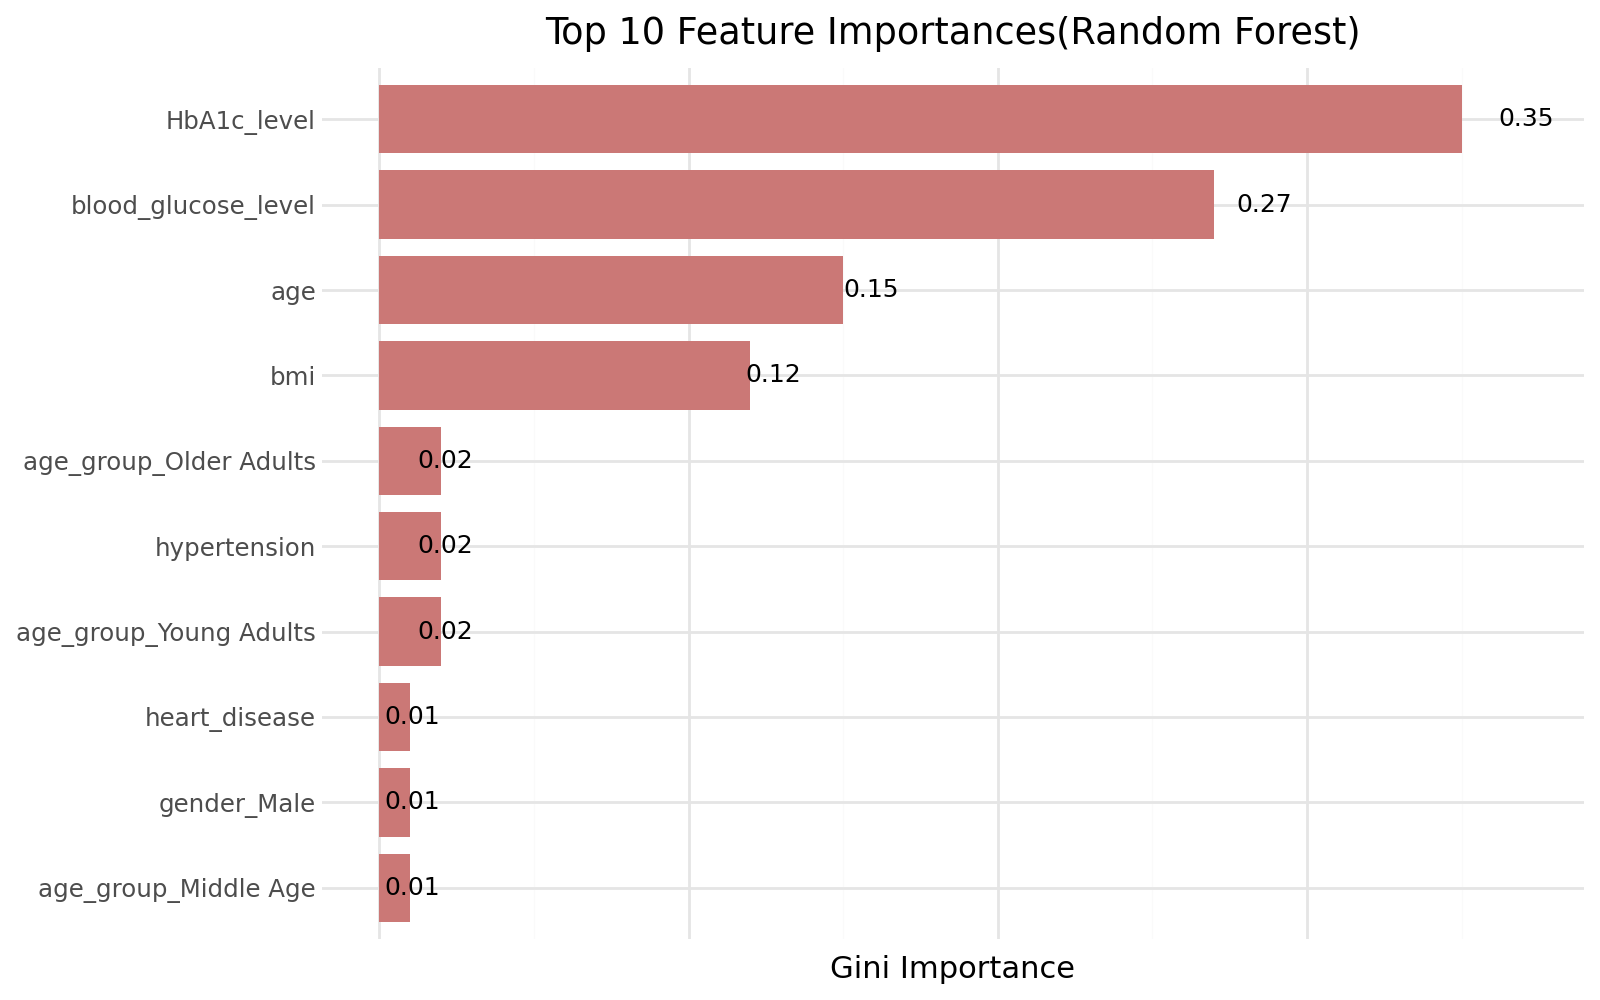

In [102]:
top_10 = feature_performance_df.sort_values(by='values', ascending=False).head(10)

chart = (ggplot(top_10, aes(x='reorder(features,values)', y='values'))
+ geom_col(width=0.8, show_legend=False, fill='#cb7876')
+ coord_flip()
+ geom_text(aes(label='values'),
            position=position_stack(vjust=1.06), size=9)
+ theme_minimal()
+ labs(title='Top 10 Feature Importances(Random Forest)',
       x='',
       y='Gini Importance')
+ theme(figure_size=(8, 5),
        axis_text_x=element_blank(),
        axis_line_y=element_blank())
)
chart

In [103]:
# Applying hyperparameter tuning with GridSearchCV 
from sklearn.model_selection import GridSearchCV

In [104]:
param_grid = {
    "max_depth": [5, 10, 20, None],
    "n_estimators": [100, 200]
}

In [105]:
grid_search = GridSearchCV(
    RandomForestClassifier(criterion="entropy", 
                           random_state=42, 
                           class_weight="balanced",
                           n_jobs=-1),
    param_grid,
    cv=5,
    scoring='recall',
    verbose=1
)

grid_search.fit(x_train_scaled_df, y_train)
print('Best Parameters:', grid_search.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'max_depth': 5, 'n_estimators': 200}


In [106]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [107]:
# using the output from the grid search to retrain on training set
rf_model2 = RandomForestClassifier(
    class_weight = "balanced",
    criterion    = "entropy",
    max_depth    = 5,
    n_estimators = 200,
    random_state = 42
)

rf_model2.fit(x_train_scaled_df, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [108]:
#Repredicting on validation set
y_val_pred_rf2  = rf_model2.predict(x_val_scaled_df)

print(classification_report(y_val, y_val_pred_rf2))

y_val_prob2 = rf_model2.predict_proba(x_val_scaled_df)[:,1]
roc_auc = roc_auc_score(y_val, y_val_prob2)
print(f'ROC-AUC SCORE:{roc_auc:.4f}')

              precision    recall  f1-score   support

           0       0.99      0.89      0.94     17533
           1       0.45      0.92      0.60      1696

    accuracy                           0.89     19229
   macro avg       0.72      0.90      0.77     19229
weighted avg       0.94      0.89      0.91     19229

ROC-AUC SCORE:0.9669


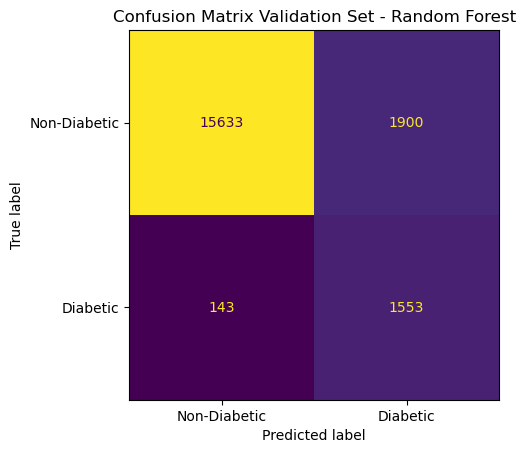

In [109]:
# Confusion Matrix for validation data

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_rf2, display_labels=['Non-Diabetic', 'Diabetic'],
                                       colorbar=False)
plt.title('Confusion Matrix Validation Set - Random Forest')
plt.show()

| | Predicted: Non-Diabetic | Predicted: Diabetic |
|---|---|---|
| **Actual: Non-Diabetic**   | **True Negative** ✅  | **False Positive** ⚠️ |
| **Actual: Diabetic**       | **False Negative** ❌ | **True Positive** ✅  |

**What each outcome means:**
- `15633` **True Negative** — Model said not diabetic, they are not diabetic.(✅ Healthy patient correctly identified as healthy)
- `1900`  **False Positive** — Model said diabetic, but they are not. Patient gets unnecessary further tests.(⚠️ Healthy patient wrongly flagged as diabetic )
- `143`  **False Negative** — Model said not diabetic, but they ARE. Patient sent home undiagnosed.(❌ Diabetic patient missed
  most dangerous outcome)
- `1553` **True Positive** — Model correctly predicted them as diabetic( ✅ Diabetic patient correctly identified )
> **recall** is the priority metric, it directly measures how well the model avoids False Negatives.

## Model Comparison Summary

| Model | Recall (Diabetic) | Precision (Diabetic) | F1 (Diabetic) | Accuracy | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression (no class weight) | 0.63 | 0.86 | 0.73 | 0.96 | 0.96 |
| Logistic Regression (balanced) | 0.88 | 0.42 | 0.57 | 0.88 | 0.96 |
| Random Forest (default) | 0.69 | 0.94 | 0.79 | 0.97 | 0.96 |
| Random Forest (GridSearchCV tuned) | **0.92** | 0.45 | 0.60 | 0.89 | 0.97 |

> **Selected Model: Tuned Random Forest**

FINAL TEST EVALUATION with Tuned Random Forest Model
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.89      0.94     17534
    Diabetic       0.44      0.91      0.60      1696

    accuracy                           0.89     19230
   macro avg       0.72      0.90      0.77     19230
weighted avg       0.94      0.89      0.91     19230

ROC-AUC SCORE: 0.9658


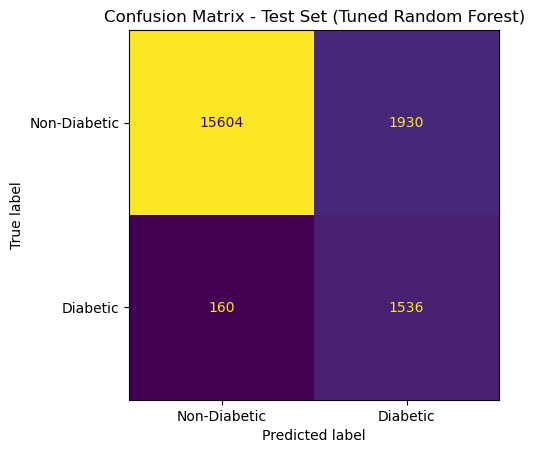

ROC-AUC SCORE:0.9658


In [110]:
# Final test prediction with best model
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x_test.columns)
y_test_pred = rf_model2.predict(x_test_scaled_df)

print('FINAL TEST EVALUATION with Tuned Random Forest Model')
print(metrics.classification_report(y_test, y_test_pred,
      target_names=['Non-Diabetic', 'Diabetic']))

y_test_prob = rf_model2.predict_proba(x_test_scaled_df)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_test_prob)
print(f'ROC-AUC SCORE: {roc_auc_test:.4f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred,
    display_labels=['Non-Diabetic', 'Diabetic'],
    colorbar=False)
plt.title('Confusion Matrix - Test Set (Tuned Random Forest)')
plt.show()

y_test_prob = rf_model2.predict_proba(x_test_scaled_df)[:,1]
roc_auc = roc_auc_score(y_test, y_test_prob)
print(f'ROC-AUC SCORE:{roc_auc:.4f}')

| | Predicted: Non-Diabetic | Predicted: Diabetic |
|---|---|---|
| **Actual: Non-Diabetic**   | **True Negative** ✅  | **False Positive** ⚠️ |
| **Actual: Diabetic**       | **False Negative** ❌ | **True Positive** ✅  |

**What each outcome means:**
- `15604` **True Negative** — Model said not diabetic, they are not diabetic.(✅ Healthy patient correctly identified as healthy)
- `1930`  **False Positive** — Model said diabetic, but they are not. Patient gets unnecessary further tests.(⚠️ Healthy patient wrongly flagged as diabetic )
- `160`  **False Negative** — Model said not diabetic, but they ARE. Patient sent home undiagnosed.(❌ Diabetic patient missed
  most dangerous outcome)
- `1536` **True Positive** — Model correctly predicted them as diabetic( ✅ Diabetic patient correctly identified )
> **recall** is the priority metric, it directly measures how well the model avoids False Negatives.

---

## Project Summary

### What the Model Learned
HbA1c and blood glucose are the strongest predictors of diabetes, each 1-unit increase in HbA1c multiplies diabetes odds by nearly 12x. This is consistent with clinical reality: HbA1c is the primary diagnostic marker for diabetes. Age and BMI follow as moderate contributors.

### Key Decisions Made
- **Class imbalance** was the biggest challenge, a default model achieved 96% accuracy while missing 37% of diabetic patients. `class_weight='balanced'` and recall-focused tuning corrected this.
- **Random Forest outperformed Logistic Regression on recall** (0.92 vs 0.88) after hyperparameter tuning but required explicit tuning to get there. Default settings produced worse results than the simpler model.
- **Recall and accuracy tell different stories.** Always choose your metric based on the real-world cost of each error type.

### Final Test Result
The tuned Random Forest correctly identified **1,536 diabetic patients** while missing only **160**, a recall of **0.92** on truly unseen data.

### Limitations
- Precision is 0.45 — nearly half of diabetic predictions are false alarms. A threshold adjustment could improve this.
- `smoking_history` contains ambiguous labels (`"No Info"`, `"ever"`) that may introduce noise.

### Next Steps
- XGBoost or a neural network may improve both recall and precision simultaneously

  ---